# Descriptive Data Analysis 

### 0. Import Modules and Data

In [2]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from itertools import combinations

os.chdir("C:\\Users\\ThinkPad\\Desktop\\llm_biases_fse\\00_data")
vignette_complete = pd.read_csv('complete_vignette_llm.csv')

os.chdir("C:\\Users\\ThinkPad\\Desktop\\llm_biases_fse\\00_data\\final_data")
# Load Data
df_llama = pd.read_csv('llama_final_data.csv')
df_qwen = pd.read_csv('qwen_final_data.csv')
df_mistral = pd.read_csv('mistral_final_data.csv')
vignette_meta = pd.read_csv('complete_vignette_llm.csv')
os.chdir("C:\\Users\\ThinkPad\\Desktop\\llm_biases_fse\\02_descriptive_analysis")

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_22956\1140414461.py:14: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_llama = pd.read_csv('llama_final_data.csv')


In [3]:
# Aggregate mean, std and NA counts by vignette_id × item_id for each model
models = {
    "llama": df_llama,
    "mistral": df_mistral,
    "qwen": df_qwen,
}

stats_dfs = {}

for name, df in models.items():
    # First, get all other columns (non-aggregated) using 'first' method
    other_cols = [col for col in df.columns if col not in ['response', 'response_recoded', 'vignette_id', 'item_id']]
    
    agg_dict = {
        'response': [
            ('response_mean', 'mean'),
            ('response_median', 'median'),
            ('response_std', 'std'),
            ('n_obs', 'count'),
            ('n_na_response', lambda x: int(x.isna().sum()))
        ],
        'response_recoded': [
            ('n_na_recoded', lambda x: int(x.isna().sum()))
        ]
    }
    
    # Add all other columns with 'first' aggregation
    for col in other_cols:
        agg_dict[col] = 'first'
    
    agg = (
        df.groupby(["vignette_id", "item_id"], as_index=False)
          .agg(
              response_mean = ("response", "mean"),
              response_median = ("response", "median"),
              response_std  = ("response", "std"),
              n_obs         = ("response", "count"),
              n_na_response = ("response", lambda x: int(x.isna().sum())),
              n_na_recoded  = ("response_recoded", lambda x: int(x.isna().sum())),
              **{col: (col, 'first') for col in other_cols}
          )
          .sort_values("response_std", ascending=False)
          .reset_index(drop=True)
    )

    stats_dfs[name] = agg
    globals()[f"df_{name}_agg"] = agg  # store in global namespace for later use

    print(f"{name} -> {agg.shape[0]} rows, {agg.shape[1]} columns. Top 10 by response_std:")
    display(agg.head(10))

llama -> 12600 rows, 17 columns. Top 10 by response_std:


,vignette_id,item_id,response_mean,response_median,response_std,n_obs,n_na_response,n_na_recoded,response_index,response_original,response_status,race,gender,gender_alignment,religion,n_dim,concept
0,vignette_9,item_72,0.840000,2.0,3.305092,100,0,0,1,-5,valid_numeric,None,man,None,None,1,CON
1,vignette_135,item_65,-2.330000,-4.0,3.156059,100,0,0,1,0,valid_numeric,Black,man,cis,jewish,4,ENV
2,vignette_30,item_72,-2.170000,-4.0,3.101173,100,0,0,1,3,valid_numeric,None,man,cis,None,2,CON
3,vignette_59,item_65,-0.720000,-2.0,3.052007,100,0,0,1,-4,valid_numeric,white,man,None,christian,3,ENV
4,vignette_21,item_72,-1.920000,-3.0,3.034082,100,0,0,1,-5,valid_numeric,None,man,None,christian,2,CON
5,vignette_137,item_65,-1.400000,-3.0,2.978034,100,0,0,1,-5,valid_numeric,white,man,cis,christian,4,ENV
6,vignette_13,item_72,-2.880000,-5.0,2.951733,100,0,0,1,-5,valid_numeric,white,man,None,None,2,CON
7,vignette_98,item_65,-1.500000,-3.0,2.945635,100,0,0,1,2,valid_numeric,None,man,cis,christian,3,ENV
8,vignette_141,item_65,-1.660000,-3.0,2.937807,100,0,0,1,3,valid_numeric,white,man,cis,jewish,4,ENV
9,vignette_1,item_54,0.173913,0.0,2.911171,92,8,8,1,5,valid_numeric,Black,None,None,None,1,PF


mistral -> 12600 rows, 17 columns. Top 10 by response_std:


,vignette_id,item_id,response_mean,response_median,response_std,n_obs,n_na_response,n_na_recoded,response_index,response_original,response_status,race,gender,gender_alignment,religion,n_dim,concept
0,vignette_9,item_36,0.210000,2.0,3.163220,100,0,0,1,"4 (I would likely refrain to some extent, but ...",extracted_numeric,None,man,None,None,1,PH
1,vignette_59,item_51,2.070000,3.0,3.147085,100,0,0,1,3,valid_numeric,white,man,None,christian,3,AF
2,vignette_1,item_43,0.430000,-1.0,3.062497,100,0,0,1,5,valid_numeric,Black,None,None,None,1,PIT
3,vignette_98,item_33,0.360000,3.0,2.942273,100,0,0,1,-2,valid_numeric,None,man,cis,christian,3,AH
4,vignette_37,item_11,1.370000,3.0,2.925523,100,0,0,1,-1,valid_numeric,Black,None,None,jewish,2,PIT
5,vignette_61,item_33,-0.320000,-2.0,2.912460,100,0,0,1,3,valid_numeric,white,man,None,jewish,3,AH
6,vignette_143,item_5,0.151515,1.0,2.897443,99,1,1,1,-3 (I would bring them up cautiously and only ...,extracted_numeric,asian,man,cis,christian,4,AH
7,vignette_4,item_33,0.840000,3.0,2.894509,100,0,0,1,-3,valid_numeric,None,None,None,christian,1,AH
8,vignette_55,item_59,0.670000,1.0,2.864111,100,0,0,1,5 (I would definitely not),extracted_numeric,None,None,trans,jewish,2,PH
9,vignette_24,item_5,0.820000,3.0,2.854661,100,0,0,1,-3,valid_numeric,None,woman,None,christian,2,AH


qwen -> 12600 rows, 17 columns. Top 10 by response_std:


,vignette_id,item_id,response_mean,response_median,response_std,n_obs,n_na_response,n_na_recoded,response_index,response_original,response_status,race,gender,gender_alignment,religion,n_dim,concept
0,vignette_95,item_44,-0.30,-5.0,5.016136,100,0,0,1,5,valid_numeric,Black,nonbinary,trans,None,3,PIT
1,vignette_152,item_59,0.30,5.0,5.016136,100,0,0,1,5,valid_numeric,Black,woman,trans,muslim,4,PH
2,vignette_143,item_49,0.40,5.0,5.009083,100,0,0,1,5,valid_numeric,asian,man,cis,christian,4,AF
3,vignette_68,item_49,0.40,5.0,5.009083,100,0,0,1,5,valid_numeric,white,woman,None,christian,3,AF
4,vignette_92,item_29,-0.03,-0.5,4.997888,100,0,0,1,5,valid_numeric,white,woman,trans,None,3,AF
5,vignette_95,item_32,0.60,5.0,4.988877,100,0,0,1,5,valid_numeric,Black,nonbinary,trans,None,3,PF
6,vignette_15,item_44,-0.70,-5.0,4.975699,100,0,0,1,-5,valid_numeric,Black,woman,None,None,2,PIT
7,vignette_167,item_32,1.00,5.0,4.923660,100,0,0,1,5,valid_numeric,Black,nonbinary,trans,christian,4,PF
8,vignette_60,item_49,-1.00,-5.0,4.923660,100,0,0,1,5,valid_numeric,white,man,None,muslim,3,AF
9,vignette_170,item_49,-1.20,-5.0,4.878317,100,0,0,1,-5,valid_numeric,white,nonbinary,trans,christian,4,AF


In [4]:
import describe_functions as dfns
from importlib import reload
dfns = reload(dfns)

In [5]:
# Merge vignette_complete into all DataFrame variables whose name starts with "df_"
# - Adds "vignette_" prefix to vignette_complete.vignette_id when missing
# - Produces new DataFrames named <orig_name>_merged (does not overwrite originals)
models = {'llama': 'df_llama', 'qwen': 'df_qwen', 'mistral': 'df_mistral'}

vc = vignette_complete.copy()
vc['vignette_id'] = vc['vignette_id'].astype(str).str.strip()
vc['vignette_id'] = vc['vignette_id'].where(vc['vignette_id'].str.startswith('vignette_'),
                                            'vignette_' + vc['vignette_id'])

merged_vars = []
for name, obj in list(globals().items()):
    if name.startswith("df_") and isinstance(obj, pd.DataFrame):
        try:
            merged = obj.merge(vc, on="vignette_id", how="left", suffixes=("", "_vign"))
            out_name = f"{name}_ready"
            globals()[out_name] = merged
            merged_vars.append(out_name)
            print(f"Created {out_name}: {merged.shape[0]} rows x {merged.shape[1]} cols")
        except Exception as e:
            print(f"Failed to merge {name}: {e}")

print(f"\nTotal merged dataframes created: {len(merged_vars)}")

Created df_llama_ready: 1260000 rows x 19 cols
Created df_qwen_ready: 1260000 rows x 19 cols
Created df_mistral_ready: 1260000 rows x 19 cols
Created df_llama_agg_ready: 12600 rows x 23 cols
Created df_mistral_agg_ready: 12600 rows x 23 cols
Created df_qwen_agg_ready: 12600 rows x 23 cols

Total merged dataframes created: 6


### 1. Item Distribution

#### a. Llama

Plot saved as: llama_response_distribution_by_item.png

📊 Llama Response Distribution Summary:
   Total unique items: 72
   Total responses: 1,259,615
   Average responses per item: 17494.7
   Response range: -5.00 to 5.00

   By concept:
     ADM: 9 items, 157500 responses, mean=4.23, std=1.30
     AF: 9 items, 157475 responses, mean=4.18, std=1.02
     AH: 9 items, 157500 responses, mean=-2.62, std=2.79
     CON: 9 items, 157435 responses, mean=-1.07, std=2.14
     ENV: 9 items, 157500 responses, mean=-0.42, std=1.78
     PF: 9 items, 157476 responses, mean=3.98, std=1.24
     PH: 9 items, 157391 responses, mean=-0.97, std=1.77
     PIT: 9 items, 157338 responses, mean=1.80, std=1.54


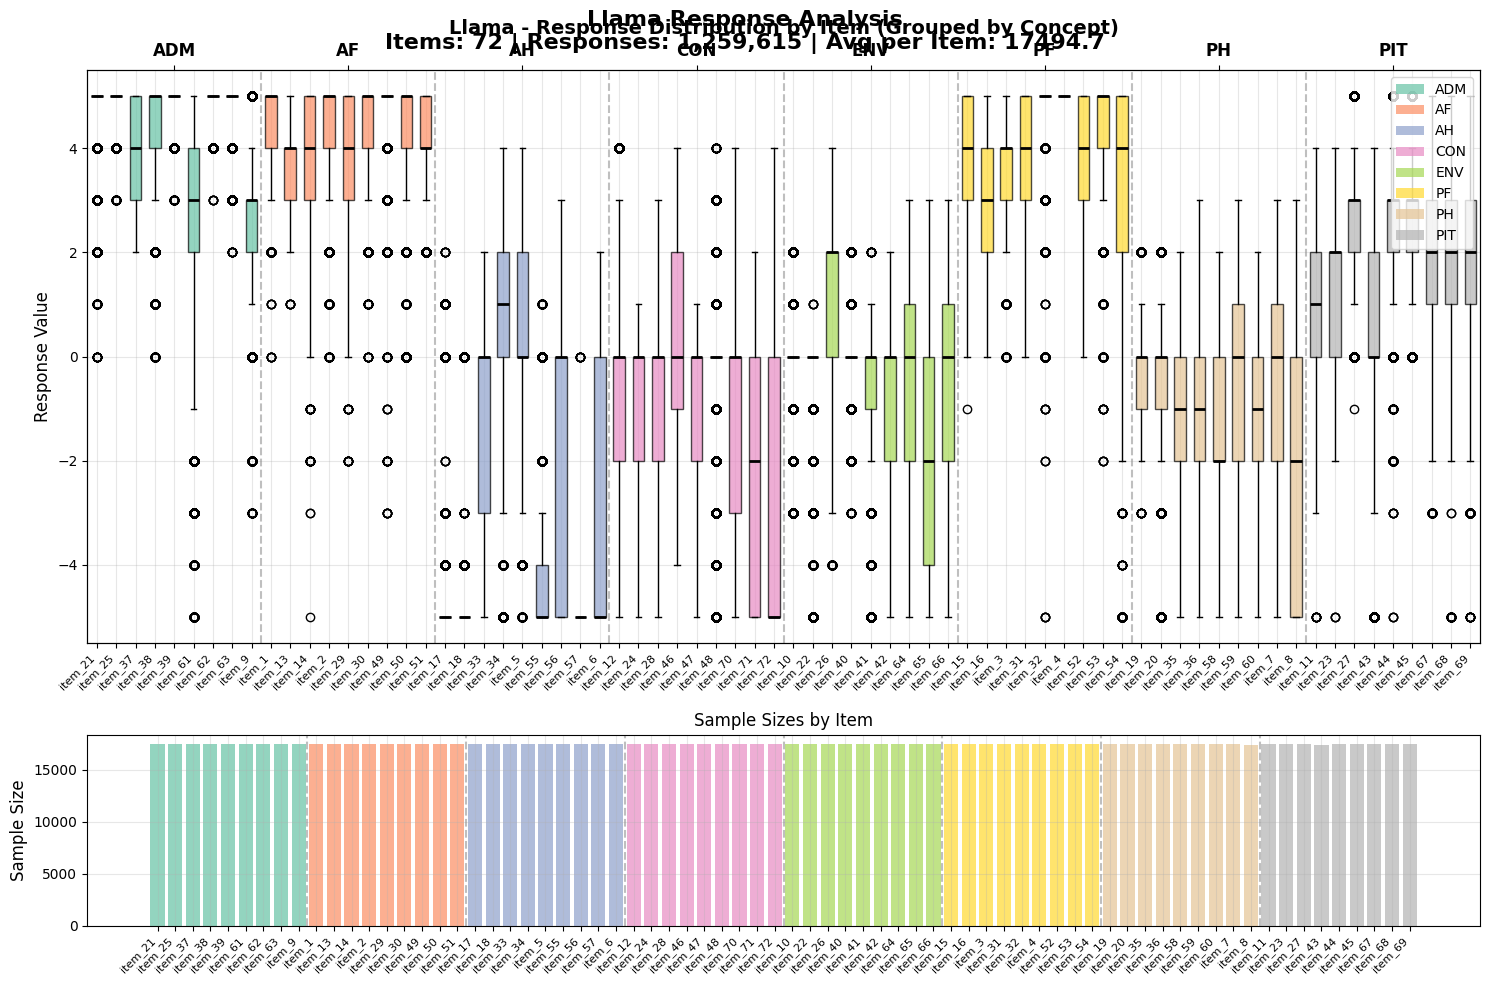

In [6]:
fig_llama = dfns.plot_response_distribution_by_item(df_llama, "Llama")
plt.show()

#### b. Mistral

Plot saved as: mistral_response_distribution_by_item.png

📊 Mistral Response Distribution Summary:
   Total unique items: 72
   Total responses: 1,255,381
   Average responses per item: 17435.8
   Response range: -5.00 to 5.00

   By concept:
     ADM: 9 items, 157472 responses, mean=4.83, std=0.54
     AF: 9 items, 157500 responses, mean=4.87, std=0.51
     AH: 9 items, 157164 responses, mean=-3.62, std=2.06
     CON: 9 items, 157449 responses, mean=-2.85, std=1.74
     ENV: 9 items, 157392 responses, mean=-0.66, std=1.45
     PF: 9 items, 156951 responses, mean=4.51, std=1.01
     PH: 9 items, 154019 responses, mean=-0.16, std=1.67
     PIT: 9 items, 157434 responses, mean=4.17, std=1.44


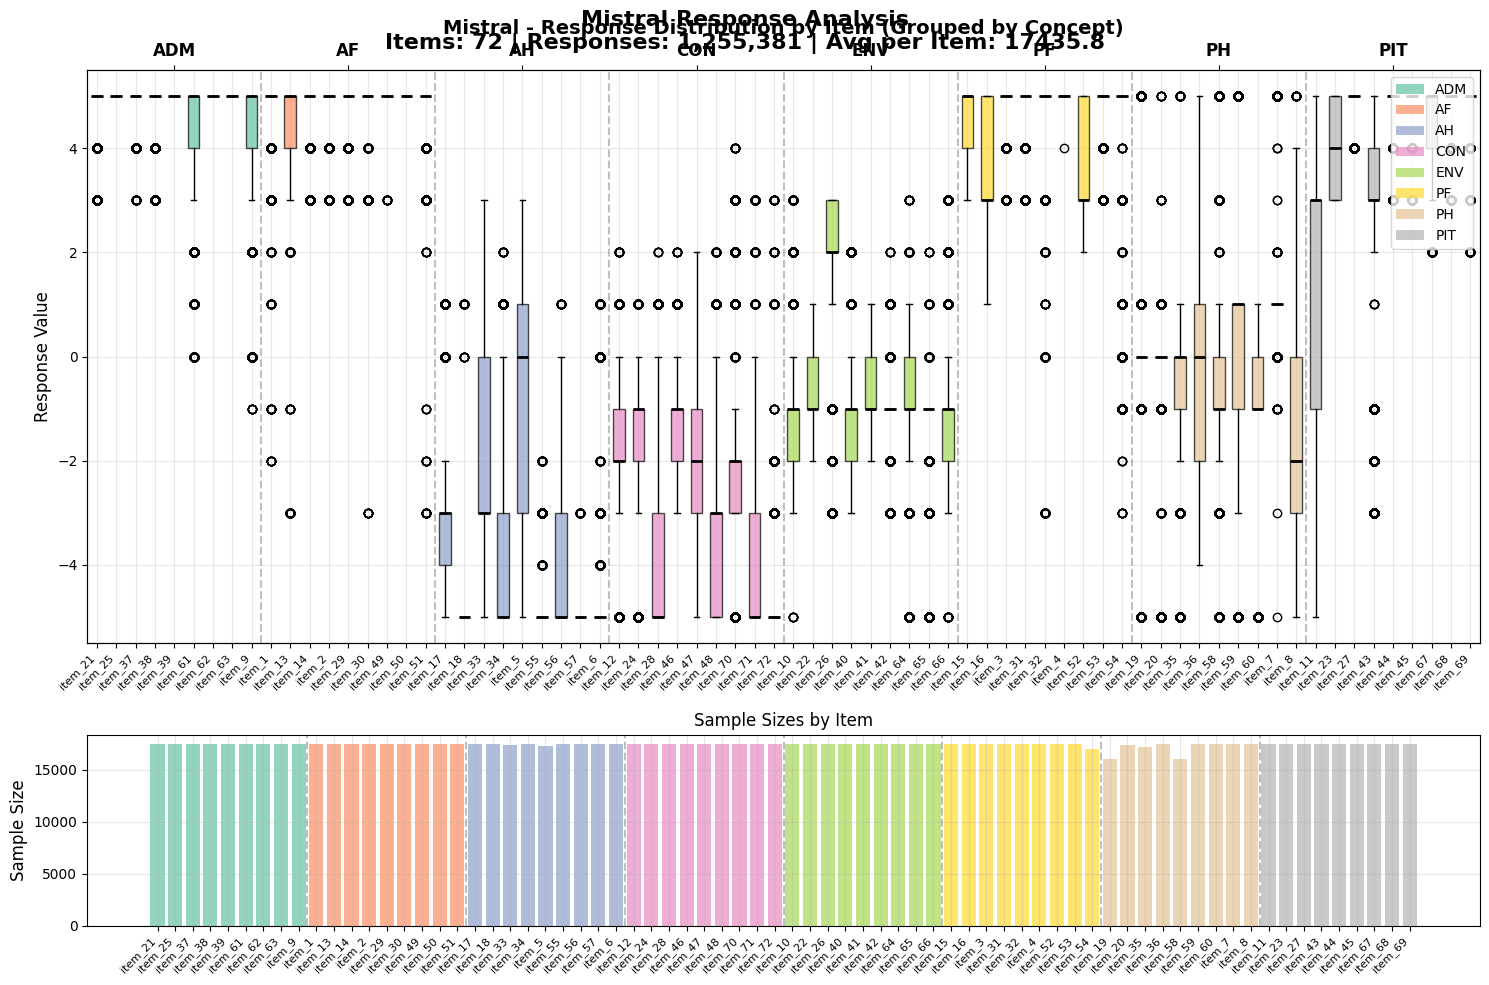

In [7]:
fig_mistral = dfns.plot_response_distribution_by_item(df_mistral, "Mistral")
plt.show()

#### c. Qwen

Plot saved as: qwen_response_distribution_by_item.png

📊 Qwen Response Distribution Summary:
   Total unique items: 72
   Total responses: 1,260,000
   Average responses per item: 17500.0
   Response range: -5.00 to 5.00

   By concept:
     ADM: 9 items, 157500 responses, mean=4.09, std=1.64
     AF: 9 items, 157500 responses, mean=1.39, std=3.70
     AH: 9 items, 157500 responses, mean=-3.11, std=1.75
     CON: 9 items, 157500 responses, mean=-0.77, std=1.92
     ENV: 9 items, 157500 responses, mean=-0.37, std=1.78
     PF: 9 items, 157500 responses, mean=1.31, std=2.99
     PH: 9 items, 157500 responses, mean=-1.96, std=2.54
     PIT: 9 items, 157500 responses, mean=-0.36, std=1.94


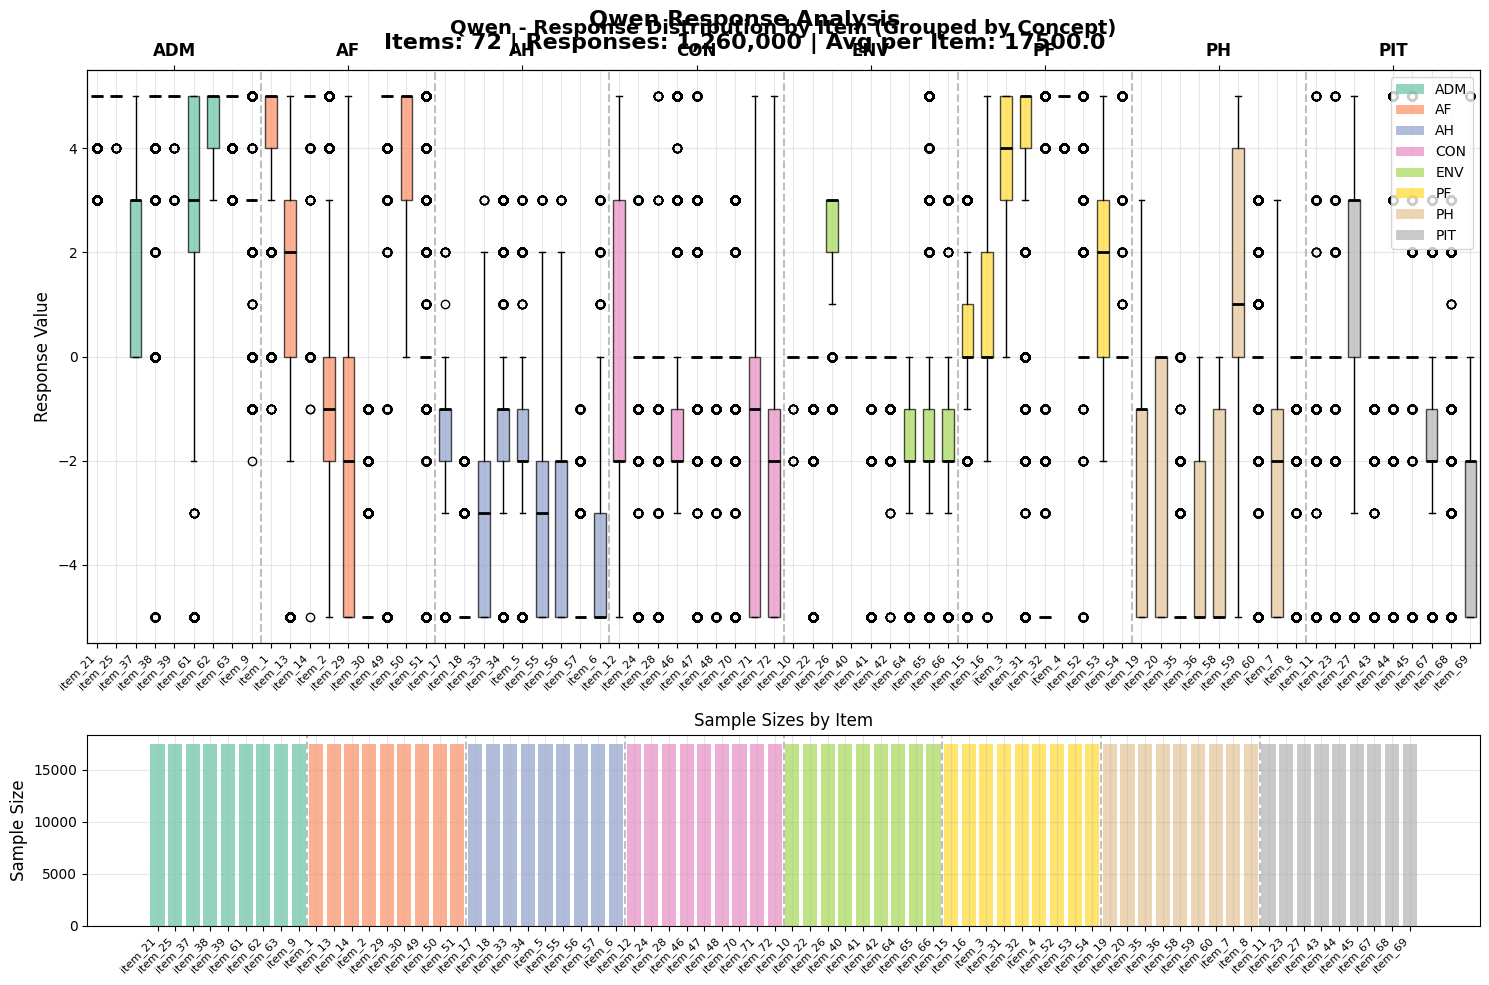

In [8]:
fig_qwen = dfns.plot_response_distribution_by_item(df_qwen, "Qwen")
plt.show()

Saved concept_stats_by_llm.csv


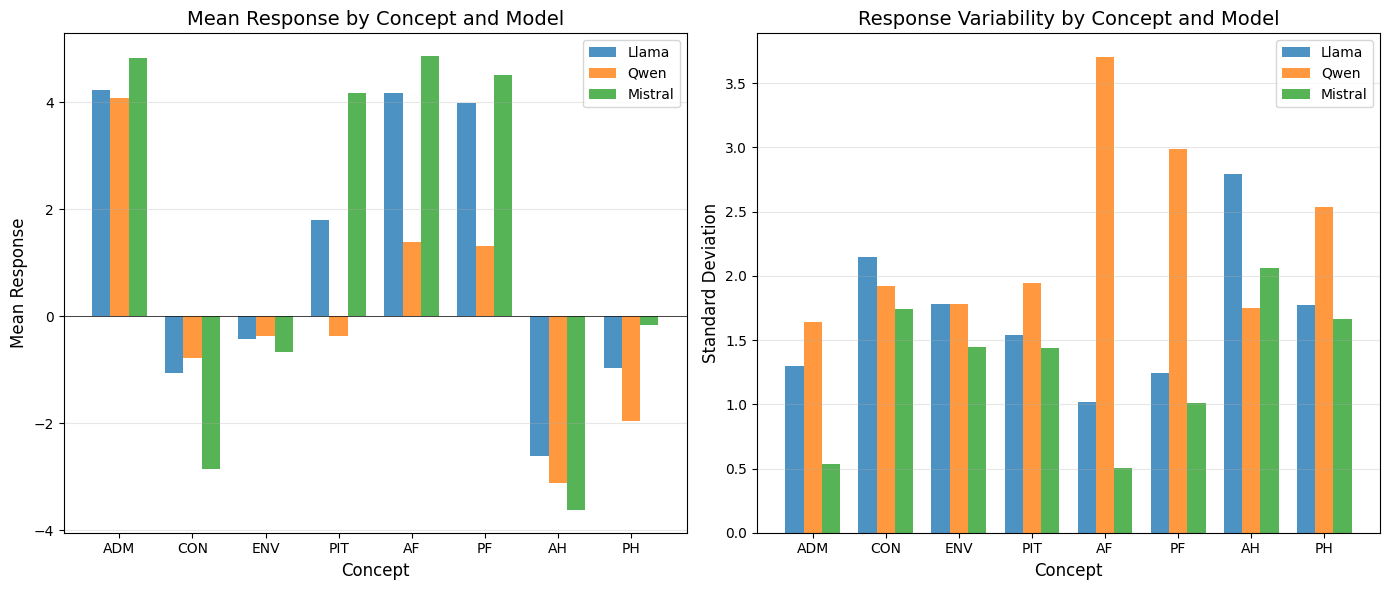

Visualization saved as 'concept_stats_visualization.png'
  concept  llama_mean  llama_std  qwen_mean  qwen_std  mistral_mean  \
0     ADM    4.227746   1.296683   4.087917  1.637486      4.833024   
1     CON   -1.066288   2.144165  -0.769429  1.919056     -2.846338   
2     ENV   -0.419676   1.778021  -0.368222  1.778534     -0.655326   
3     PIT    1.796845   1.541060  -0.356679  1.943323      4.170891   
4      AF    4.180708   1.016491   1.391562  3.703209      4.867873   
5      PF    3.983197   1.240020   1.313759  2.986995      4.506470   
6      AH   -2.616229   2.792899  -3.113365  1.748160     -3.618259   
7      PH   -0.971606   1.769973  -1.955079  2.539996     -0.155318   

   mistral_std  
0     0.535008  
1     1.742609  
2     1.445018  
3     1.436691  
4     0.505743  
5     1.011143  
6     2.060596  
7     1.667085  


In [9]:
# Compute mean and std per concept for each model
llama_stats = df_llama.groupby('concept')['response'].agg(['mean', 'std']).reset_index()
llama_stats.columns = ['concept', 'llama_mean', 'llama_std']

qwen_stats = df_qwen.groupby('concept')['response'].agg(['mean', 'std']).reset_index()
qwen_stats.columns = ['concept', 'qwen_mean', 'qwen_std']

mistral_stats = df_mistral.groupby('concept')['response'].agg(['mean', 'std']).reset_index()
mistral_stats.columns = ['concept', 'mistral_mean', 'mistral_std']

# Merge all together
concept_stats = llama_stats.merge(qwen_stats, on='concept', how='outer')
concept_stats = concept_stats.merge(mistral_stats, on='concept', how='outer')

# Define the new concept order
concept_order = ["ADM", "CON", "ENV", "PIT", "AF", "PF", "AH", "PH"]

# Sort by the new order
concept_stats['concept'] = pd.Categorical(concept_stats['concept'], categories=concept_order, ordered=True)
concept_stats = concept_stats.sort_values('concept').reset_index(drop=True)

# Save to CSV
concept_stats.to_csv('concept_stats_by_llm.csv', index=False)
print("Saved concept_stats_by_llm.csv")

# Create visualization of concept stats
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mean comparison across models
x = range(len(concept_stats))
width = 0.25

ax1.bar([i - width for i in x], concept_stats['llama_mean'], width, label='Llama', alpha=0.8)
ax1.bar([i for i in x], concept_stats['qwen_mean'], width, label='Qwen', alpha=0.8)
ax1.bar([i + width for i in x], concept_stats['mistral_mean'], width, label='Mistral', alpha=0.8)

ax1.set_xlabel('Concept', fontsize=12)
ax1.set_ylabel('Mean Response', fontsize=12)
ax1.set_title('Mean Response by Concept and Model', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(concept_stats['concept'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Plot 2: Standard deviation comparison
ax2.bar([i - width for i in x], concept_stats['llama_std'], width, label='Llama', alpha=0.8)
ax2.bar([i for i in x], concept_stats['qwen_std'], width, label='Qwen', alpha=0.8)
ax2.bar([i + width for i in x], concept_stats['mistral_std'], width, label='Mistral', alpha=0.8)

ax2.set_xlabel('Concept', fontsize=12)
ax2.set_ylabel('Standard Deviation', fontsize=12)
ax2.set_title('Response Variability by Concept and Model', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(concept_stats['concept'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('concept_stats_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'concept_stats_visualization.png'")
print(concept_stats)

Saved concept_stats_by_llm.csv


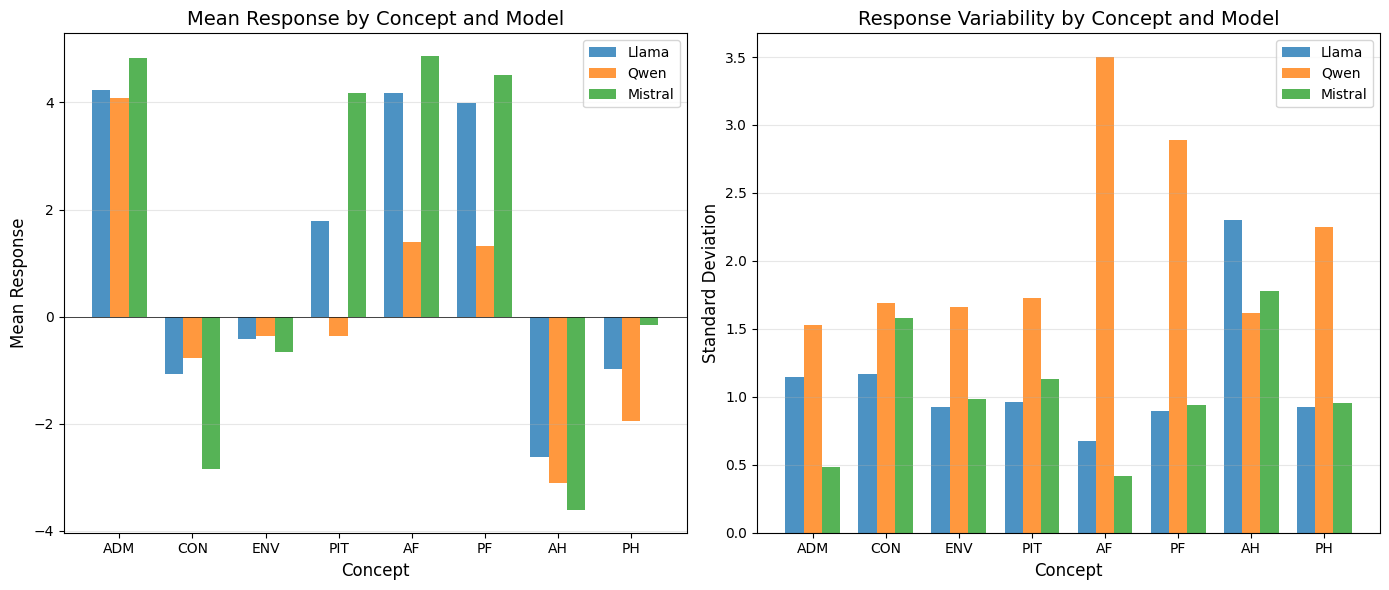

Visualization saved as 'concept_stats_aggregated_visualization.png'
  concept  llama_mean  llama_std  qwen_mean  qwen_std  mistral_mean  \
0     ADM    4.227746   1.145797   4.087917  1.526637      4.832642   
1     CON   -1.066503   1.164148  -0.769429  1.687946     -2.845852   
2     ENV   -0.419676   0.928331  -0.368222  1.660679     -0.655496   
3     PIT    1.794915   0.964594  -0.356679  1.729048      4.169904   
4      AF    4.180602   0.674921   1.391562  3.499170      4.867873   
5      PF    3.982714   0.893865   1.313759  2.889499      4.504409   
6      AH   -2.616229   2.301173  -3.113365  1.613834     -3.613933   
7      PH   -0.973152   0.927168  -1.955079  2.251351     -0.151608   

   mistral_std  
0     0.485648  
1     1.581388  
2     0.983005  
3     1.129218  
4     0.415589  
5     0.936924  
6     1.781156  
7     0.957323  


In [10]:
# Compute mean and std per concept for each model
llama_stats = df_llama_agg.groupby('concept')['response_mean'].agg(['mean', 'std']).reset_index()
llama_stats.columns = ['concept', 'llama_mean', 'llama_std']

qwen_stats = df_qwen_agg.groupby('concept')['response_mean'].agg(['mean', 'std']).reset_index()
qwen_stats.columns = ['concept', 'qwen_mean', 'qwen_std']

mistral_stats = df_mistral_agg.groupby('concept')['response_mean'].agg(['mean', 'std']).reset_index()
mistral_stats.columns = ['concept', 'mistral_mean', 'mistral_std']

# Merge all together
concept_stats = llama_stats.merge(qwen_stats, on='concept', how='outer')
concept_stats = concept_stats.merge(mistral_stats, on='concept', how='outer')

# Define the new concept order
concept_order = ["ADM", "CON", "ENV", "PIT", "AF", "PF", "AH", "PH"]

# Sort by the new order
concept_stats['concept'] = pd.Categorical(concept_stats['concept'], categories=concept_order, ordered=True)
concept_stats = concept_stats.sort_values('concept').reset_index(drop=True)

# Save to CSV
concept_stats.to_csv('concept_stats_by_llm.csv', index=False)
print("Saved concept_stats_by_llm.csv")

# Create visualization of concept stats
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mean comparison across models
x = range(len(concept_stats))
width = 0.25

ax1.bar([i - width for i in x], concept_stats['llama_mean'], width, label='Llama', alpha=0.8)
ax1.bar([i for i in x], concept_stats['qwen_mean'], width, label='Qwen', alpha=0.8)
ax1.bar([i + width for i in x], concept_stats['mistral_mean'], width, label='Mistral', alpha=0.8)

ax1.set_xlabel('Concept', fontsize=12)
ax1.set_ylabel('Mean Response', fontsize=12)
ax1.set_title('Mean Response by Concept and Model', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(concept_stats['concept'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Plot 2: Standard deviation comparison
ax2.bar([i - width for i in x], concept_stats['llama_std'], width, label='Llama', alpha=0.8)
ax2.bar([i for i in x], concept_stats['qwen_std'], width, label='Qwen', alpha=0.8)
ax2.bar([i + width for i in x], concept_stats['mistral_std'], width, label='Mistral', alpha=0.8)

ax2.set_xlabel('Concept', fontsize=12)
ax2.set_ylabel('Standard Deviation', fontsize=12)
ax2.set_title('Response Variability by Concept and Model', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(concept_stats['concept'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('concept_stats_aggregated_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'concept_stats_aggregated_visualization.png'")
print(concept_stats)

#### a. Llama

Plot saved as: llama_means_by_demographics.png

📊 Llama Demographics Summary:

   ADM:
     race:
       Black: 4.54 (n=39600)
       asian: 4.38 (n=39600)
       white: 3.84 (n=39600)
     gender:
       man: 4.06 (n=43200)
       nonbinary: 4.51 (n=28800)
       woman: 4.30 (n=43200)
     religion:
       christian: 4.09 (n=39600)
       jewish: 4.30 (n=39600)
       muslim: 4.38 (n=39600)
     gender_alignment:
       cis: 3.89 (n=43200)
       trans: 4.53 (n=57600)

   AF:
     race:
       Black: 4.45 (n=39587)
       asian: 4.31 (n=39600)
       white: 3.86 (n=39588)
     gender:
       man: 3.91 (n=43184)
       nonbinary: 4.49 (n=28800)
       woman: 4.28 (n=43191)
     religion:
       christian: 4.02 (n=39591)
       jewish: 4.32 (n=39600)
       muslim: 4.32 (n=39584)
     gender_alignment:
       cis: 3.87 (n=43200)
       trans: 4.54 (n=57575)

   AH:
     race:
       Black: -3.04 (n=39600)
       asian: -2.56 (n=39600)
       white: -2.39 (n=39600)
     gender:
       ma

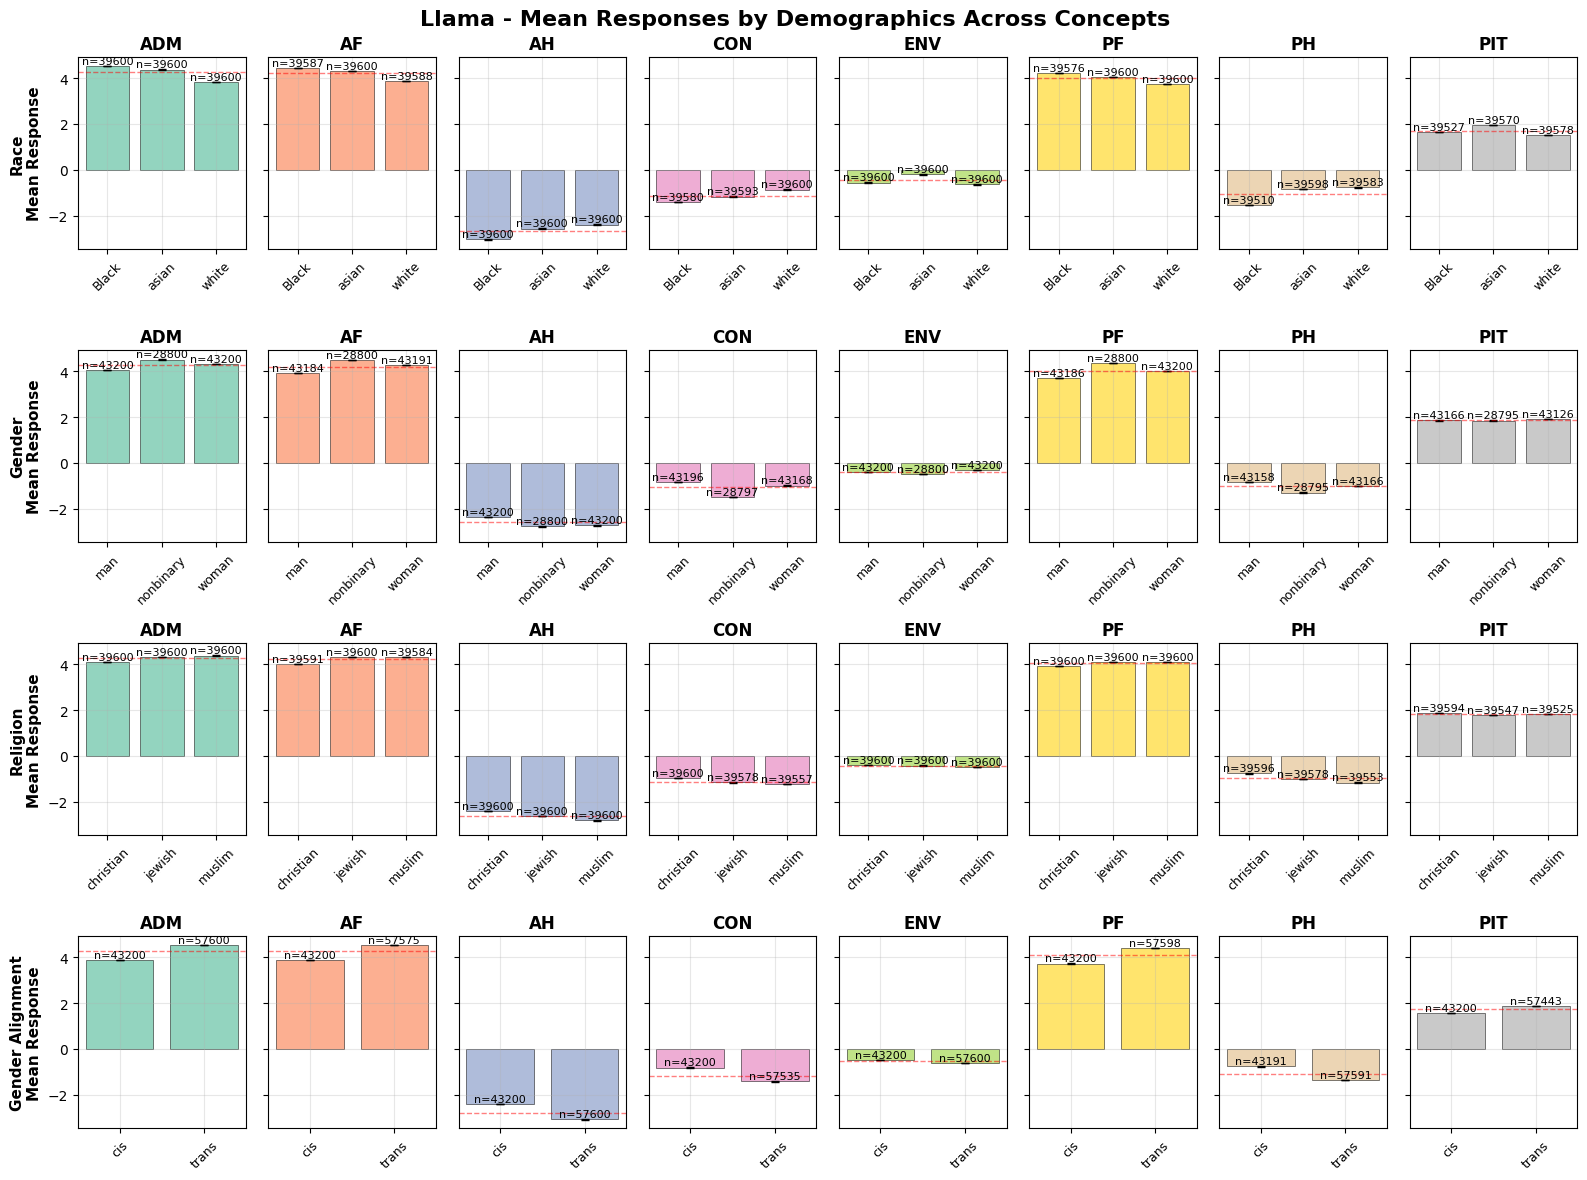

Plot saved as: llama_demographics_comparison.png


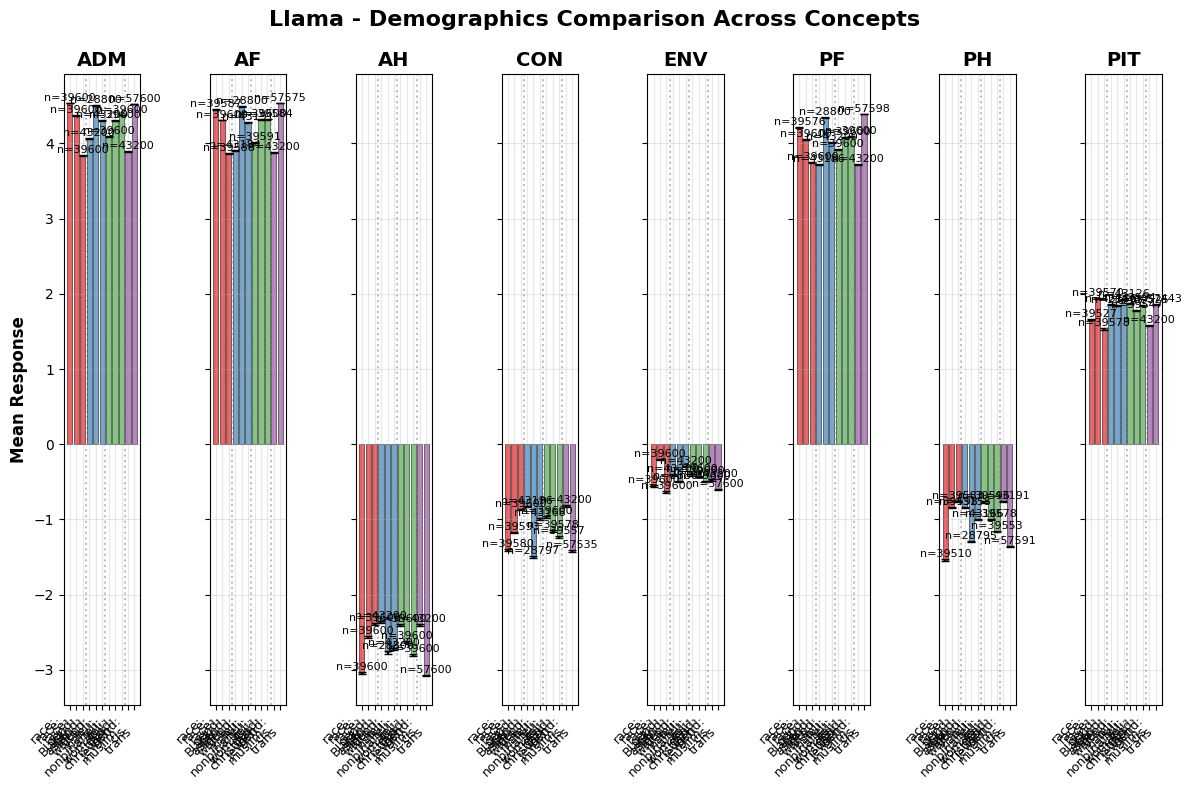

In [11]:
# Detailed grid plot (demographics × concepts)
fig1 = dfns.plot_means_by_demographics(df_llama, "Llama")
plt.show()

# Simplified comparison plot
fig2 = dfns.plot_demographic_comparison_single(df_llama, "Llama")
plt.show()

In [12]:
reload(dfns)

<module 'describe_functions' from 'C:\\Users\\ThinkPad\\Desktop\\llm_biases_fse\\02_descriptive_analysis\\describe_functions.py'>

# Histograms Answer Distribution

In [19]:
dfns = reload(dfns)

In [24]:
figs, y_max, yticks = dfns.plot_response_histograms_fixed_scale(
    dfs=[df_llama, df_mistral, df_qwen],
    model_names=["Llama", "Mistral", "Qwen"],
    col="response_recoded",  
    font_scale=1.9,
    figsize=(12, 8),
    save=True,
    out_dir="plots/hist_response_recoded"
)

In [25]:
figs, y_max, yticks = dfns.plot_response_histograms_fixed_scale(
    dfs=[df_llama, df_mistral, df_qwen],
    model_names=["Llama", "Mistral", "Qwen"],
    col="response",
    font_scale=1.9,
    figsize=(12, 8),
    save=True,
    out_dir="plots/hist_response"
)

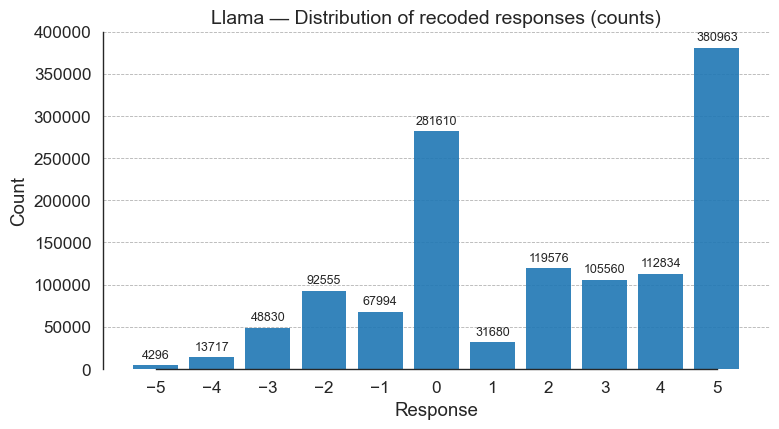

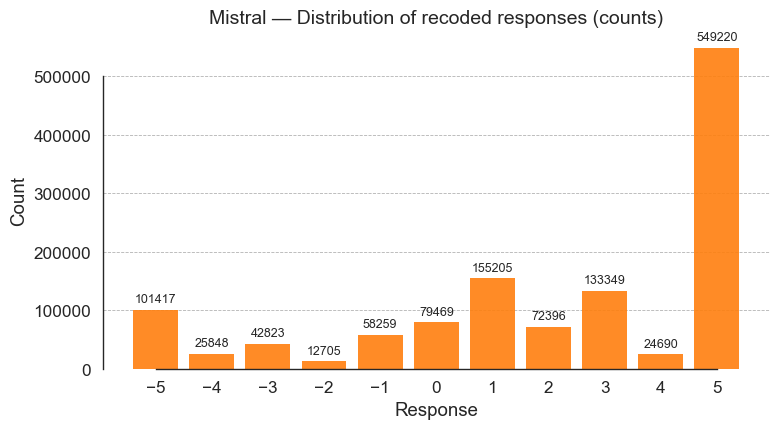

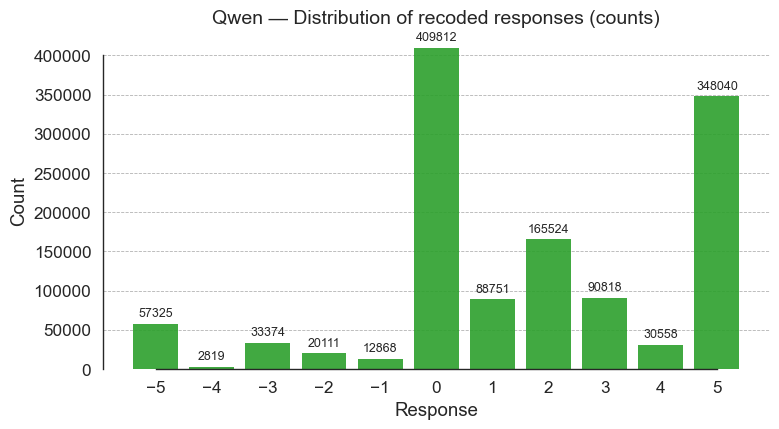

In [37]:
# Publication-quality histograms of responserecoded for each model

# Generate and save plots for each dataframe
plots_rec = {}
plots_rec["Llama"] = dfns.plot_response_recoded_histogram(df_llama, "Llama")
plots_rec["Mistral"] = dfns.plot_response_recoded_histogram(df_mistral, "Mistral")
plots_rec["Qwen"] = dfns.plot_response_recoded_histogram(df_qwen, "Qwen")

# Observed Group Means for Overall Response

Combined vignette means (head):
    vignette_id  mean_llama  mean_qwen  mean_mistral
0    vignette_1    2.101782   2.220556      2.558865
1   vignette_10    1.183889   1.021667      1.777577
2  vignette_100    1.651389   1.063056      1.921716
3  vignette_101    2.115417   1.658611      2.350223
4  vignette_102    1.583333   1.186250      1.741689
Saved combined vignette means to 'vignette_means_by_model.xlsx'

Correlation between vignette means:
              mean_llama  mean_qwen  mean_mistral
mean_llama      1.000000   0.899365      0.897584
mean_qwen       0.899365   1.000000      0.832198
mean_mistral    0.897584   0.832198      1.000000


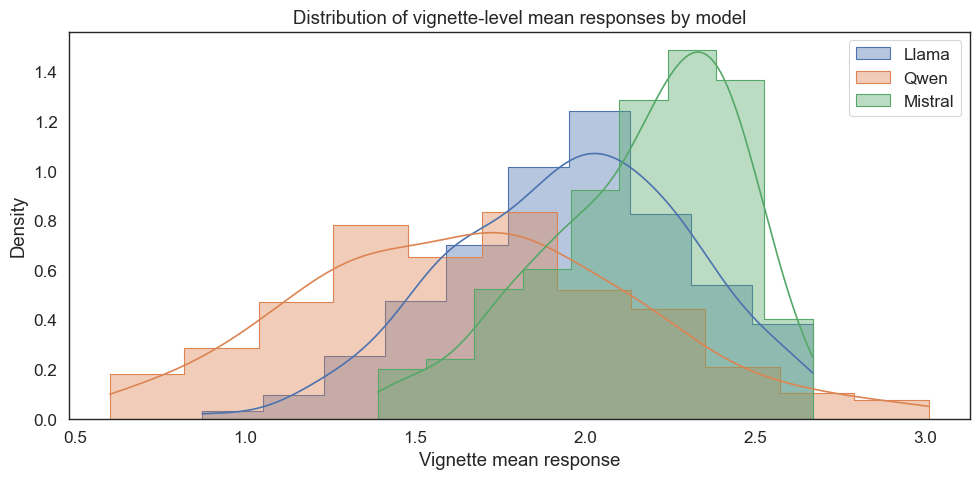

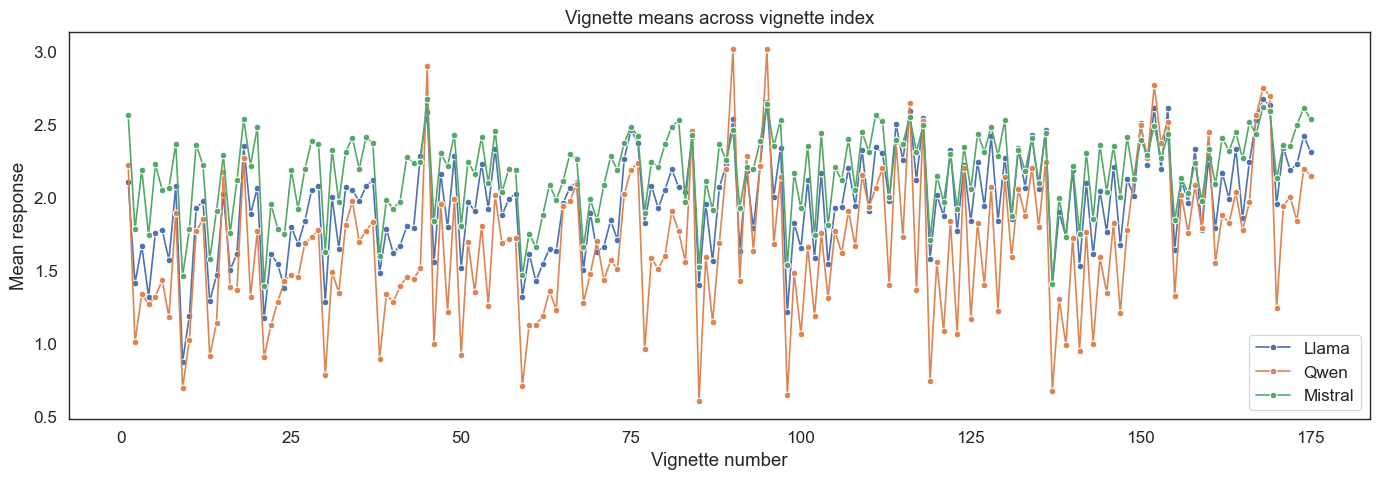

In [38]:
# Calculate vignette-level means (and std, n) for each model, create comparison table and plots

models = {
    'Llama': df_llama,
    'Qwen': df_qwen,
    'Mistral': df_mistral,
}

def compute_vignette_means(df, model_name):
    g = (
        df.groupby('vignette_id')['response_recoded']
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .rename(columns={'mean': 'response_mean',
                         'std': 'response_std',
                         'count': 'n_obs'})
    )

    # Extract trailing number for plotting
    try:
        g['vignette_num'] = g['vignette_id'].str.extract(r'(\d+)$').astype(int)
    except Exception:
        g['vignette_num'] = range(1, len(g) + 1)

    g['model'] = model_name
    return g

vignette_means = {name: compute_vignette_means(df, name) for name, df in models.items()}

# Combined table (wide) for easy comparisons
combined = (
    vignette_means['Llama'][['vignette_id', 'response_mean']]
    .rename(columns={'response_mean': 'mean_llama'})
    .merge(
        vignette_means['Qwen'][['vignette_id', 'response_mean']]
        .rename(columns={'response_mean': 'mean_qwen'}),
        on='vignette_id',
        how='outer'
    )
    .merge(
        vignette_means['Mistral'][['vignette_id', 'response_mean']]
        .rename(columns={'response_mean': 'mean_mistral'}),
        on='vignette_id',
        how='outer'
    )
)


# show summary of combined table
print("Combined vignette means (head):")
print(combined.head())


# Save to Excel for later inspection
combined.to_excel('vignette_means_by_model.xlsx', index=False)
print("Saved combined vignette means to 'vignette_means_by_model.xlsx'")

# Correlation between model vignette means
corr_cols = ['mean_llama', 'mean_qwen', 'mean_mistral']
corr = combined[corr_cols].corr()
print("\nCorrelation between vignette means:")
print(corr)

# Plots
plt.figure(figsize=(10, 5))
# Overlaid histograms / density of vignette means
for name, g in vignette_means.items():
    sns.histplot(g['response_mean'].dropna(), kde=True, stat='density', label=name, element='step', alpha=0.4)
plt.xlabel('Vignette mean response')
plt.title('Distribution of vignette-level mean responses by model')
plt.legend()
plt.tight_layout()
plt.show()

# Line plot across vignette_num to see per-vignette variation (sorted by vignette number)
plt.figure(figsize=(14, 5))
for name, g in vignette_means.items():
    gg = g.sort_values('vignette_num')
    sns.lineplot(x='vignette_num', y='response_mean', data=gg, marker='o', label=name)
plt.xlabel('Vignette number')
plt.ylabel('Mean response')
plt.title('Vignette means across vignette index')
plt.legend()
plt.tight_layout()
plt.show()



### Plot Deviations Overall Response 

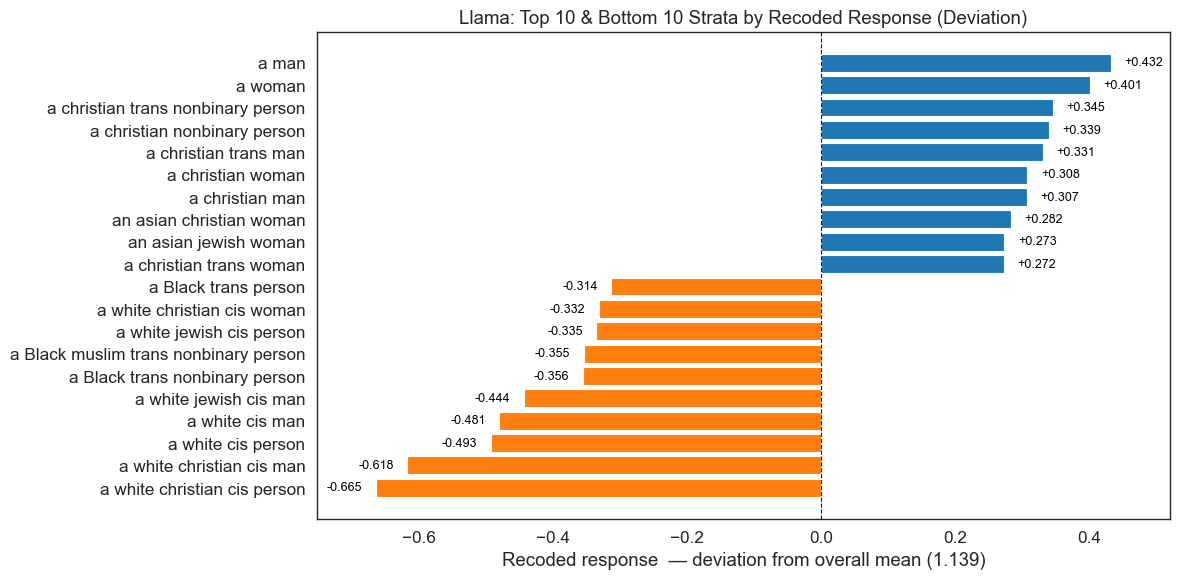

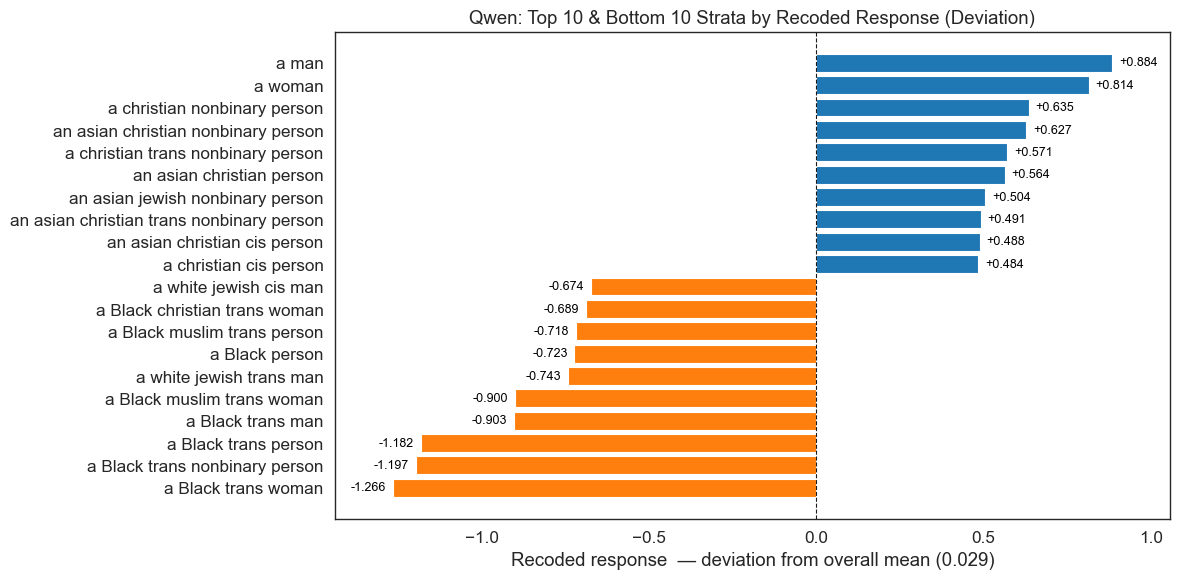

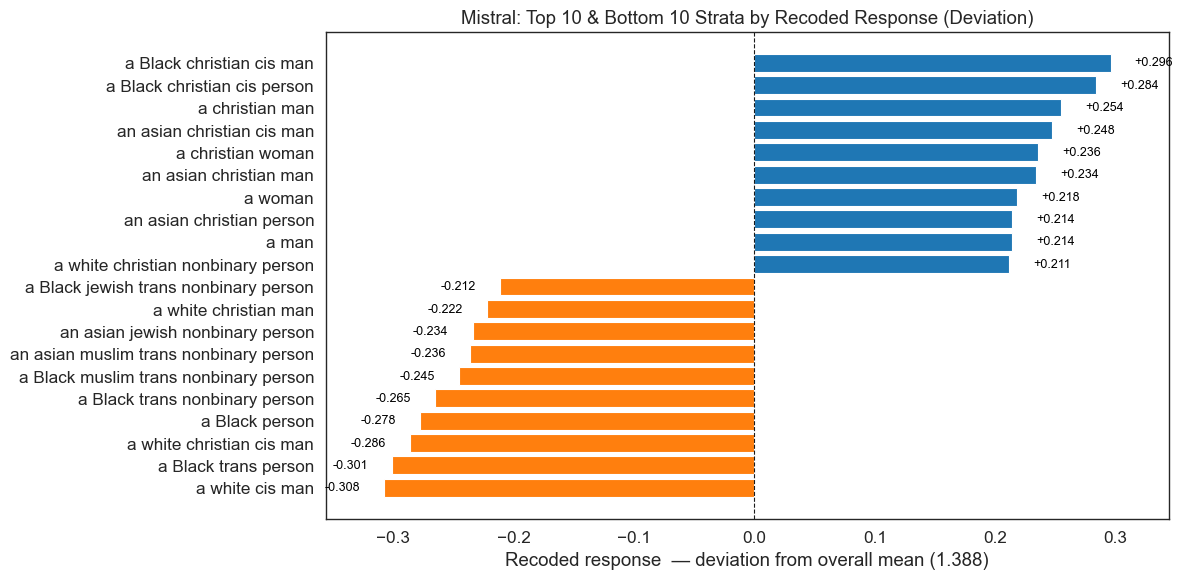

In [39]:
def plot_stratum_deviation_per_model(df_model, model_name, response_col="response_recoded", n=10, figsize=(8, 6)):
    """
    Plot deviation of stratum mean from overall mean for a single model.
    Shows top n and bottom n strata (by mean of response_col) as deviations.
    Expects df_model to contain columns: 'stratum' and response_col.
    """
    df_model = df_model.rename(columns={"vignette_complete": "stratum"})
    if "stratum" not in df_model.columns:
        print(f"Model {model_name} has no 'stratum' column. Skipping.")
        return

    grp = df_model.dropna(subset=["stratum", response_col]).groupby("stratum")[response_col].mean()
    if grp.empty:
        print(f"No valid stratum data for {model_name}. Skipping.")
        return

    overall_mean = grp.mean()
    dev = grp - overall_mean

    top = dev.nlargest(n)
    bottom = dev.nsmallest(n)

    combined = pd.concat([top, bottom])
    combined = combined.loc[~combined.index.isna()]
    combined = combined.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=figsize)
    colors = ["tab:orange" if v < 0 else "tab:blue" for v in combined.values]
    ax.barh(combined.index.astype(str), combined.values, color=colors)
    ax.axvline(0, color="k", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"Recoded response  — deviation from overall mean ({overall_mean:.3f})")
    ax.set_title(f"{model_name}: Top {n} & Bottom {n} Strata by Recoded Response (Deviation)")
    ax.invert_yaxis()
    # Extend x-axis limits to make room for labels
    x_min, x_max = combined.min(), combined.max()
    x_range = x_max - x_min
    ax.set_xlim(x_min - 0.08 * x_range, x_max + 0.08 * x_range)

    for x, y in zip(combined.values, combined.index.astype(str)):
        offset = 0.02 if x >= 0 else -0.02
        ha = "left" if x >= 0 else "right"
        ax.text(x + offset, y, f"{x:+.3f}", va="center", ha=ha, color="black", fontsize=9)
   
    plt.tight_layout()
    plt.show()


# Run for each model (uses existing df_*_ready variables)
plot_stratum_deviation_per_model(df_llama_item_stats_merged, "Llama", response_col="response_mean", n=10, figsize=(12, 6))
plot_stratum_deviation_per_model(df_qwen_item_stats_merged,  "Qwen",  response_col="response_mean", n=10, figsize=(12, 6))
plot_stratum_deviation_per_model(df_mistral_item_stats_merged,"Mistral",response_col="response_mean", n=10, figsize=(12, 6))

## Cronbachs Alpha concepts LLama

In [40]:
import pandas as pd
import numpy as np

# First aggregate over 100 reps
df_llama_agg = df_llama.groupby(["vignette_id", "item_id", "concept"], as_index=False).agg(response_mean =("response_recoded", "mean"))
# ------------------------------------------------------------
# Pivot: jede Zeile = Vignette, jede Spalte = Item
# ------------------------------------------------------------
wide_llama = df_llama_agg.pivot_table(
    index="vignette_id",
    columns="item_id",
    values="response_mean",
    aggfunc="mean"
)

print(f"Wide DataFrame: {wide_llama.shape[0]} Vignetten × {wide_llama.shape[1]} Items")






Wide DataFrame: 175 Vignetten × 72 Items


## Cronbachs Alpha concepts Mistral

In [41]:

# First aggregate over 100 reps
df_mistral_agg = df_mistral.groupby(["vignette_id", "item_id", "concept"], as_index=False).agg(response_mean =("response_recoded", "mean"))
# ------------------------------------------------------------
# 1️⃣ Pivot: jede Zeile = Vignette, jede Spalte = Item
# ------------------------------------------------------------
wide_mistral = df_mistral_agg.pivot_table(
    index="vignette_id",
    columns="item_id",
    values="response_mean",
    aggfunc="mean"
)

print(f"Wide DataFrame: {wide_mistral.shape[0]} Vignetten × {wide_mistral.shape[1]} Items")



Wide DataFrame: 175 Vignetten × 72 Items


## Cronbachs Alpha concepts Qwen

In [42]:

# First aggregate over 100 reps
df_qwen_agg = df_qwen.groupby(["vignette_id", "item_id", "concept"], as_index=False).agg(response_mean =("response_recoded", "mean"))
# ------------------------------------------------------------
# 1️⃣ Pivot: jede Zeile = Vignette, jede Spalte = Item
# ------------------------------------------------------------
wide_qwen = df_qwen_agg.pivot_table(
    index="vignette_id",
    columns="item_id",
    values="response_mean",
    aggfunc="mean"
)

print(f"Wide DataFrame: {wide_qwen.shape[0]} Vignetten × {wide_qwen.shape[1]} Items")




Wide DataFrame: 175 Vignetten × 72 Items


In [43]:
# ------------------------------------------------------------
# 2️⃣ Mapping: welchem Konzept gehört welches Item?
# ------------------------------------------------------------
item_concept_map = df.drop_duplicates("item_id")[["item_id", "concept"]].set_index("item_id")["concept"]

# ------------------------------------------------------------
# 3️⃣ Cronbach's α Funktion
# ------------------------------------------------------------
def cronbach_alpha(df_items):
    X = np.asarray(df_items)
    k = X.shape[1]
    if k <= 1:
        return np.nan
    item_vars = X.var(axis=0, ddof=1)
    total_var = X.sum(axis=1).var(ddof=1)
    return (k/(k-1)) * (1 - item_vars.sum()/total_var)

# ------------------------------------------------------------
# α für jedes Konzept berechnen
# ------------------------------------------------------------
alphas = {}
for concept, items in item_concept_map.groupby(item_concept_map):
    concept_items = items.index.intersection(wide_llama.columns)
    if len(concept_items) < 2:
        continue  # zu wenige Items für Alpha
    alpha = cronbach_alpha(wide_llama[concept_items].dropna())
    alphas[concept] = alpha

alphas_df = pd.DataFrame.from_dict(alphas, orient="index", columns=["Cronbach_alpha"])
alphas_df = alphas_df.sort_values("Cronbach_alpha", ascending=False)
print("\nCronbach’s α per concept Llama:")
print(alphas_df.round(3))


# ------------------------------------------------------------
alphas = {}
for concept, items in item_concept_map.groupby(item_concept_map):
    concept_items = items.index.intersection(wide_mistral.columns)
    if len(concept_items) < 2:
        continue  # zu wenige Items für Alpha
    alpha = cronbach_alpha(wide_mistral[concept_items].dropna())
    alphas[concept] = alpha

alphas_df = pd.DataFrame.from_dict(alphas, orient="index", columns=["Cronbach_alpha"])
alphas_df = alphas_df.sort_values("Cronbach_alpha", ascending=False)
print("\nCronbach’s α per concept Mistral:")
print(alphas_df.round(3))

# ------------------------------------------------------------
alphas = {}
for concept, items in item_concept_map.groupby(item_concept_map):
    concept_items = items.index.intersection(wide_qwen.columns)
    if len(concept_items) < 2:
        continue  # zu wenige Items für Alpha
    alpha = cronbach_alpha(wide_qwen[concept_items].dropna())
    alphas[concept] = alpha

alphas_df = pd.DataFrame.from_dict(alphas, orient="index", columns=["Cronbach_alpha"])
alphas_df = alphas_df.sort_values("Cronbach_alpha", ascending=False)
print("\nCronbach’s α per concept Qwen:")
print(alphas_df.round(3))


Cronbach’s α per concept Llama:
     Cronbach_alpha
AF            0.956
CON           0.912
PH            0.902
PF            0.888
ADM           0.846
AH            0.833
ENV           0.817
PIT           0.810

Cronbach’s α per concept Mistral:
     Cronbach_alpha
CON           0.923
AH            0.895
PIT           0.870
AF            0.863
PF            0.819
ADM           0.723
ENV           0.401
PH            0.143

Cronbach’s α per concept Qwen:
     Cronbach_alpha
AH            0.895
PH            0.867
CON           0.806
ADM           0.735
PF            0.679
PIT           0.614
AF            0.585
ENV           0.578


# Spider Plots to Visualize Concepts

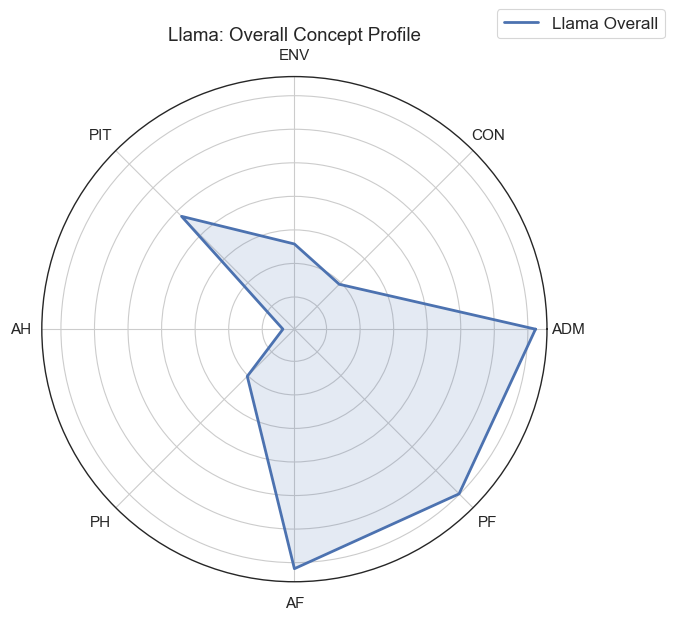

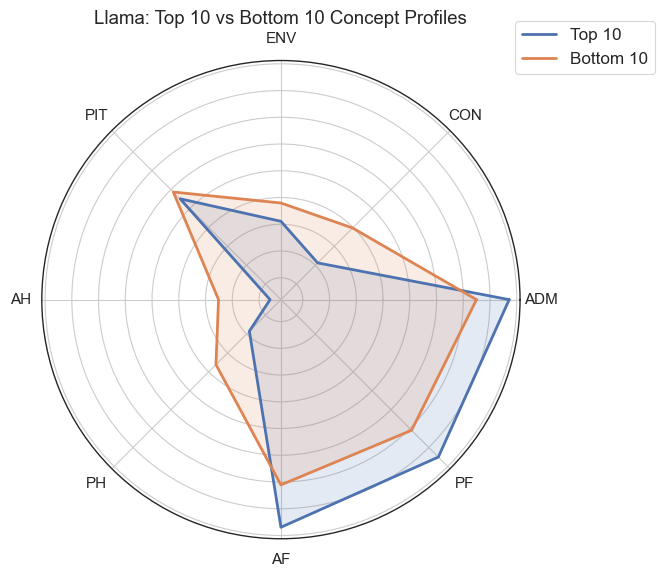


Saved concept_summary_top10_bottom10_Llama.xlsx
  Concept  Top10_Mean  Bottom10_Mean  Diff_TopMinusBottom
0     ADM    4.716333       3.494000             1.222333
1     CON   -1.876215      -0.029778            -1.846437
2     ENV   -0.890111      -0.205111            -0.685000
3     PIT    1.515351       1.872222            -0.356872
4      AH   -3.412778      -1.486000            -1.926778
5      PH   -2.149889      -0.383000            -1.766889
6      AF    4.693276       3.108889             1.584387
7      PF    4.506179       3.090778             1.415401


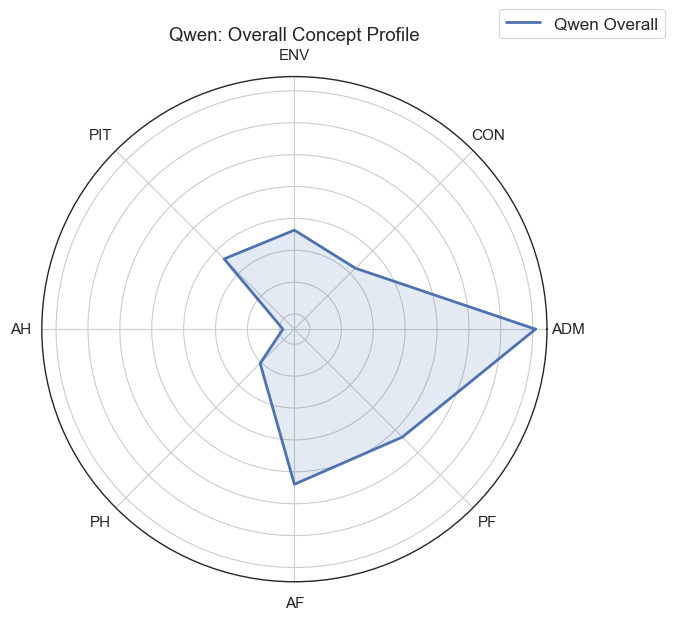

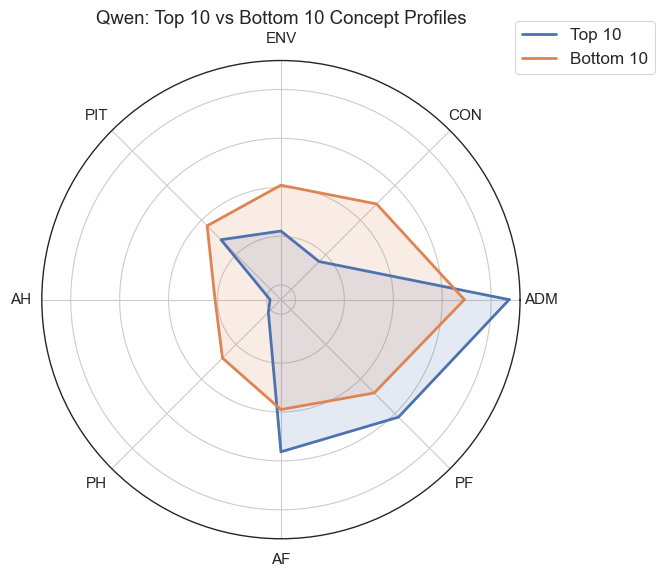


Saved concept_summary_top10_bottom10_Qwen.xlsx
  Concept  Top10_Mean  Bottom10_Mean  Diff_TopMinusBottom
0     ADM    4.738333       2.906778             1.831556
1     CON   -2.389222       0.938889            -3.328111
2     ENV   -1.787889       0.085778            -1.873667
3     PIT   -1.129222      -0.326556            -0.802667
4      AH   -4.149111      -1.900000            -2.249111
5      PH   -3.867000      -1.215333            -2.651667
6      AF    1.628778      -0.099333             1.728111
7      PF    2.201889       0.801333             1.400556


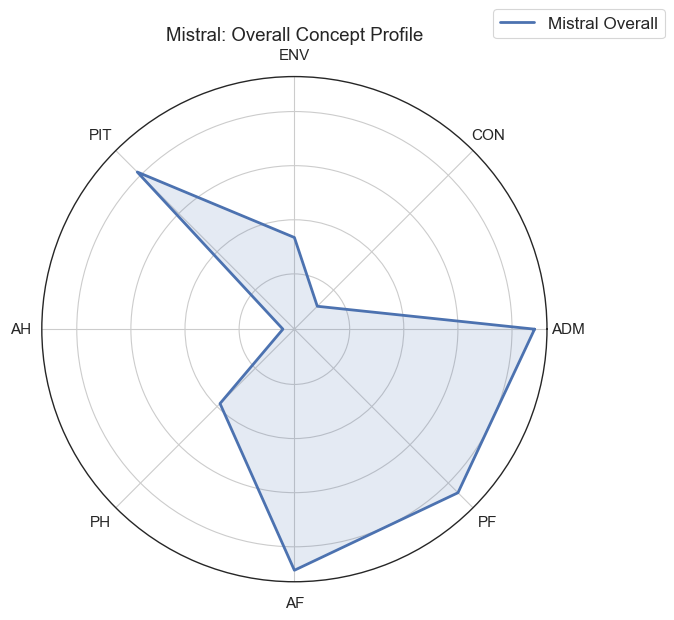

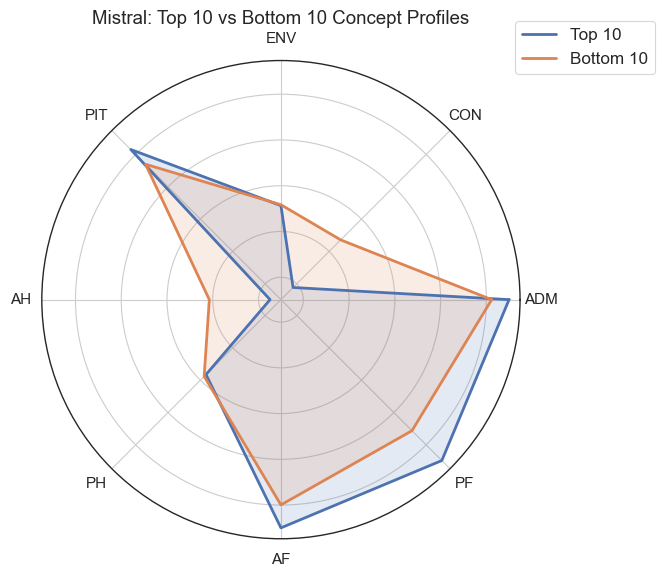


Saved concept_summary_top10_bottom10_Mistral.xlsx
  Concept  Top10_Mean  Bottom10_Mean  Diff_TopMinusBottom
0     ADM    4.993444       4.235236             0.758209
1     CON   -4.230000      -1.286033            -2.943967
2     ENV   -0.870205      -0.830381            -0.039824
3     PIT    4.302267       3.390987             0.911281
4      AH   -4.505527      -1.850305            -2.655222
5      PH   -0.348193      -0.234019            -0.114174
6      AF    4.998556       3.994667             1.003889
7      PF    4.967899       3.123126             1.844773


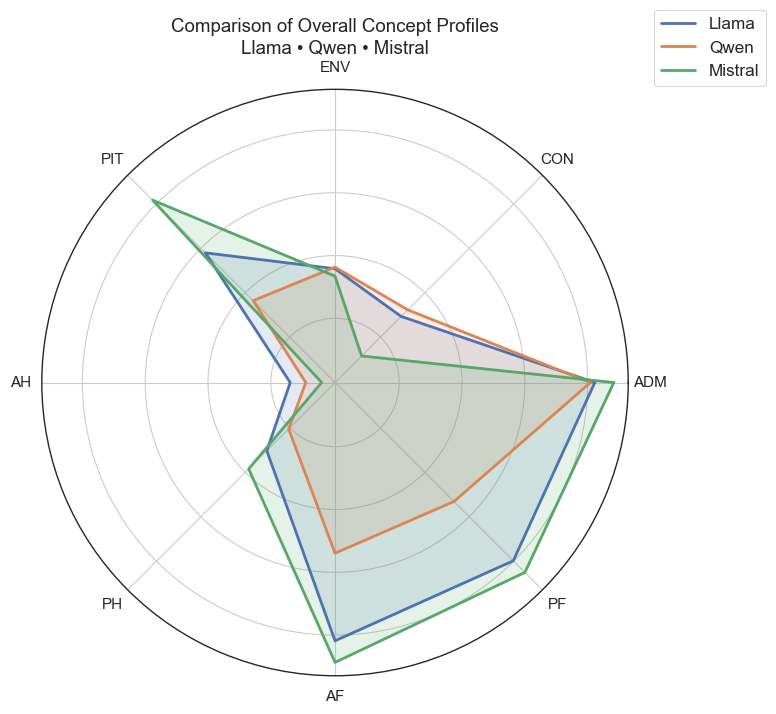

In [44]:
# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
concept_list = ["ADM", "CON", "ENV", "PIT", "AH", "PH", "AF", "PF"]

models = {
    "Llama": df_llama,
    "Qwen": df_qwen,
    "Mistral": df_mistral,
}

# ---------------------------------------------------------
# Helper: radar chart
# ---------------------------------------------------------
def plot_radar(ax, values, categories, label=None):
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    values = values.tolist()
    values += values[:1]
    angles += angles[:1]

    ax.plot(angles, values, linewidth=2, label=label)
    ax.fill(angles, values, alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_yticklabels([])
    ax.grid(True)

# ---------------------------------------------------------
# Compute vignette-level CONCEPT means (pivot from long → wide)
# ---------------------------------------------------------
def compute_concept_means(df):
    """
    df must contain: vignette_id, concept, response
    """
    g = df.groupby(["vignette_id", "concept"])["response"].mean().reset_index()
    wide = g.pivot(index="vignette_id", columns="concept", values="response")
    wide = wide.reset_index()
    return wide

# ---------------------------------------------------------
# Compute vignette-level RATING means (response_recoded)
# ---------------------------------------------------------
def compute_response_means(df):
    return (
        df.groupby("vignette_id")["response_recoded"]
        .mean()
        .reset_index()
        .rename(columns={"response_recoded": "response_mean"})
    )

# ---------------------------------------------------------
# PREPARE DATA
# ---------------------------------------------------------
concept_means = {}
response_means = {}
merged = {}

for model_name, df in models.items():

    # Long format → wide format for concepts
    concept_means[model_name] = compute_concept_means(df)

    # Mean response_recoded for ranking
    response_means[model_name] = compute_response_means(df)

    # Merge into single table
    merged_df = response_means[model_name].merge(
        concept_means[model_name], on="vignette_id", how="left"
    )

    merged[model_name] = merged_df

# ---------------------------------------------------------
# OPTION A OUTPUTS
# ---------------------------------------------------------
for model_name in models.keys():

    df_v = merged[model_name]

    # -----------------------------
    # 1. Radar plot: overall mean
    # -----------------------------
    overall_mean = df_v[concept_list].mean()

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    plot_radar(ax, overall_mean, concept_list, label=f"{model_name} Overall")
    plt.title(f"{model_name}: Overall Concept Profile")
    plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.15))
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 2. Top 10 vs Bottom 10 radar
    # -----------------------------
    top10 = df_v.nlargest(10, "response_mean")
    bottom10 = df_v.nsmallest(10, "response_mean")

    top10_mean = top10[concept_list].mean()
    bottom10_mean = bottom10[concept_list].mean()

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    plot_radar(ax, top10_mean, concept_list, label="Top 10")
    plot_radar(ax, bottom10_mean, concept_list, label="Bottom 10")
    plt.title(f"{model_name}: Top 10 vs Bottom 10 Concept Profiles")
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 3. Summary table
    # -----------------------------
    summary_table = pd.DataFrame({
        "Concept": concept_list,
        "Top10_Mean": top10_mean.values,
        "Bottom10_Mean": bottom10_mean.values,
        "Diff_TopMinusBottom": (top10_mean - bottom10_mean).values
    })

    summary_table.to_excel(f"concept_summary_top10_bottom10_{model_name}.xlsx", index=False)
    print(f"\nSaved concept_summary_top10_bottom10_{model_name}.xlsx")
    print(summary_table)

# ---------------------------------------------------------
# 4. Combined radar plot for all 3 models
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model_name in models.keys():
    mean_profile = merged[model_name][concept_list].mean()
    plot_radar(ax, mean_profile, concept_list, label=model_name)

plt.title("Comparison of Overall Concept Profiles\nLlama • Qwen • Mistral")
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.15))
plt.tight_layout()
plt.show()


# individual profiles

In [45]:
# prepare vignette_meta keys to match "vignette_#" format and create mapping
vm = vignette_meta.copy()
vm['vignette_id'] = 'vignette_' + vm['vignette_id'].astype(str)
mapping = vm.set_index('vignette_id')['vignette_complete'].to_dict()

# target dataframes to update (only update if they exist in the notebook)
targets = ['df', 'df_all', 'df_llama', 'df_qwen', 'df_mistral']

for name in targets:
    if name in globals():
        df_target = globals()[name]
        if 'vignette_id' in df_target.columns:
            df_target['vignette_complete'] = df_target['vignette_id'].map(mapping)
            globals()[name] = df_target  # put back into global namespace
            print(f"Updated {name}: added 'vignette_complete' ({df_target['vignette_complete'].notna().sum()} non-null)")

Updated df: added 'vignette_complete' (1260000 non-null)
Updated df_llama: added 'vignette_complete' (1260000 non-null)
Updated df_qwen: added 'vignette_complete' (1260000 non-null)
Updated df_mistral: added 'vignette_complete' (1260000 non-null)


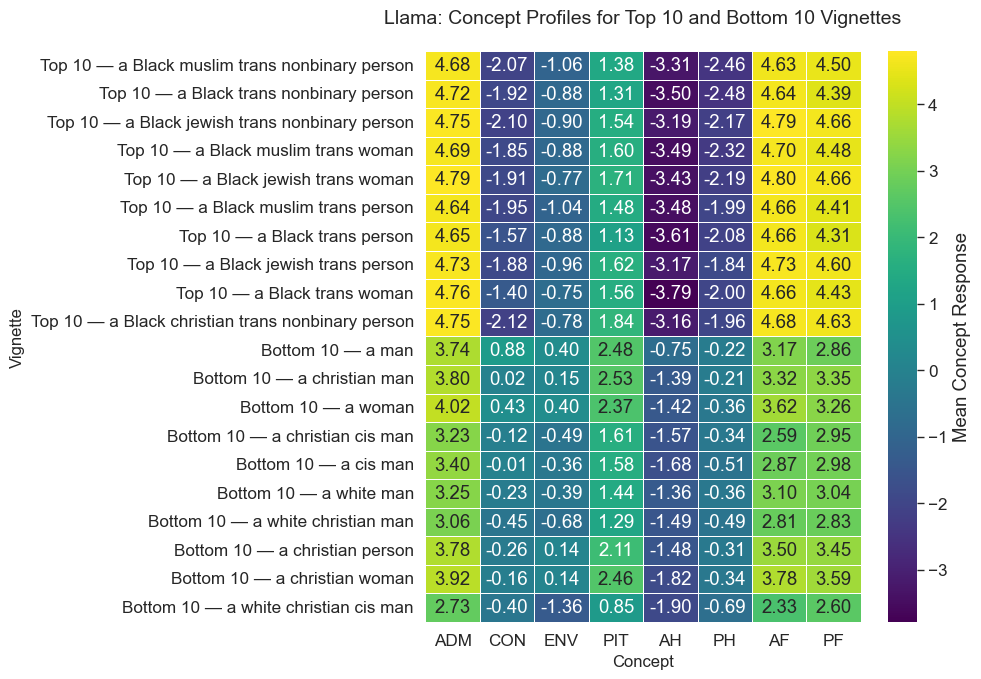

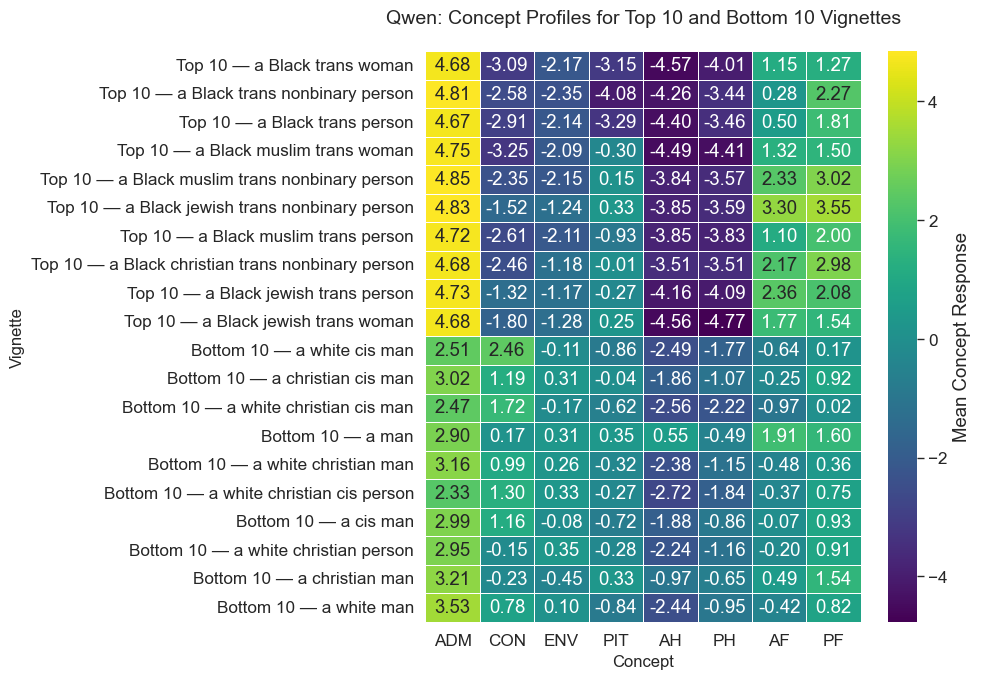

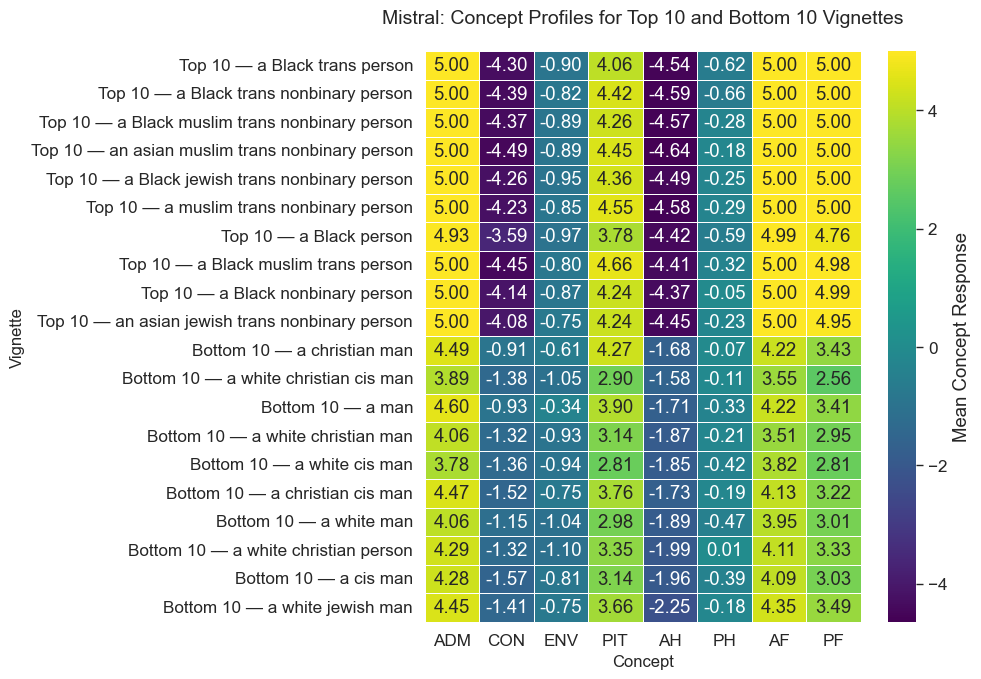

In [46]:
# ----------------------------------------------------------
# CONFIG
# ----------------------------------------------------------
concept_order = ["ADM", "CON", "ENV", "PIT", "AH", "PH", "AF", "PF"]

def plot_top_bottom_heatmap(df_model, model_name):
    """
    df_model must contain:
        vignette_complete, concept, response, response_recoded
    """

    # 1. Compute vignette-level means for ranking
    vignette_scores = (
        df_model.groupby("vignette_complete")["response_recoded"]
        .mean()
        .reset_index()
        .rename(columns={"response_recoded": "response_mean"})
    )

    # 2. Identify Top 10 and Bottom 10 vignette IDs
    top10_ids = vignette_scores.nlargest(10, "response_mean")["vignette_complete"].tolist()
    bottom10_ids = vignette_scores.nsmallest(10, "response_mean")["vignette_complete"].tolist()

    # 3. Compute mean concept scores per vignette (wide format)
    df_concepts = (
        df_model.groupby(["vignette_complete", "concept"])["response"]
        .mean()
        .reset_index()
        .pivot(index="vignette_complete", columns="concept", values="response")
        .reindex(columns=concept_order)
    )

    # Keep only top/bottom 10 and add a group label
    df_sel = df_concepts.loc[top10_ids + bottom10_ids].copy()
    df_sel["Group"] = ["Top 10"] * 10 + ["Bottom 10"] * 10

    # Add readable row labels
    df_sel["Label"] = df_sel["Group"] + " — " + df_sel.index.astype(str)

    # Final matrix for heatmap
    heatmap_data = df_sel.set_index("Label")[concept_order]

    # ----------------------------------------------------------
    # PLOT
    # ----------------------------------------------------------
    plt.figure(figsize=(10, 7))

    sns.heatmap(
        heatmap_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"label": "Mean Concept Response"},
        vmin=heatmap_data.values.min(),
        vmax=heatmap_data.values.max()
    )

    plt.title(f"{model_name}: Concept Profiles for Top 10 and Bottom 10 Vignettes",
              pad=20, fontsize=14)

    plt.xlabel("Concept", fontsize=12)
    plt.ylabel("Vignette", fontsize=12)

    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------
# RUN FOR EACH MODEL
# ----------------------------------------------------------
plot_top_bottom_heatmap(df_llama, "Llama")
plot_top_bottom_heatmap(df_qwen, "Qwen")
plot_top_bottom_heatmap(df_mistral, "Mistral")

## For each concept: top and bottom 10


In [47]:
def top_n_vignettes_by_concept(df, concepts=concept_list, n=10, response_col='response'):
    """
    Returns a DataFrame with one column per concept. Each column lists the vignette_id
    of the top-n vignette means (by response_col) for that concept.
    """
    cols = {}
    for c in concepts:
        # compute vignette-level mean response for this concept
        series = (
            df.loc[df['concept'] == c]
              .groupby('vignette_complete')[response_col]
              .mean()
              .dropna()
              .sort_values(ascending=False)
        )
        top_ids = series.head(n).index.tolist()
        # pad to length n for consistent dataframe shape
        if len(top_ids) < n:
            top_ids += [pd.NA] * (n - len(top_ids))
        cols[c] = top_ids
    return pd.DataFrame(cols)

# Generate tables for each model
top10_llama = top_n_vignettes_by_concept(df_llama)
top10_qwen = top_n_vignettes_by_concept(df_qwen)
top10_mistral = top_n_vignettes_by_concept(df_mistral)

# Show results
print("Top 10 vignette_ids per concept — Llama")
display(top10_llama)
print("\nTop 10 vignette_ids per concept — Qwen")
display(top10_qwen)
print("\nTop 10 vignette_ids per concept — Mistral")
display(top10_mistral)

# Optionally save to Excel
with pd.ExcelWriter("top10_vignettes_by_concept_per_model.xlsx") as w:
    top10_llama.to_excel(w, sheet_name="Llama_top10", index_label="rank")
    top10_qwen.to_excel(w, sheet_name="Qwen_top10", index_label="rank")
    top10_mistral.to_excel(w, sheet_name="Mistral_top10", index_label="rank")

print("Saved top10_vignettes_by_concept_per_model.xlsx")

Top 10 vignette_ids per concept — Llama


,ADM,CON,ENV,PIT,AH,PH,AF,PF
0,a Black jewish trans woman,a man,a man,a christian trans man,a man,a christian man,a Black jewish trans woman,a Black jewish trans nonbinary person
1,a Black trans woman,a woman,a woman,a christian trans woman,a white man,a man,a Black jewish trans nonbinary person,a Black jewish trans woman
2,a Black christian trans nonbinary person,a christian man,an asian christian woman,a christian man,a christian man,an asian man,a Black jewish trans person,a Black christian trans nonbinary person
3,a Black jewish trans nonbinary person,a cis man,an asian woman,a christian nonbinary person,a woman,an asian christian person,a Black christian trans woman,a Black jewish trans man
4,a Black jewish trans man,a christian cis man,an asian jewish woman,a man,a white jewish man,a christian person,a Black jewish nonbinary person,a Black jewish trans person
5,a Black jewish nonbinary person,a christian woman,a christian man,a christian woman,a christian person,an asian christian cis man,a Black christian trans person,a Black christian trans person
6,a Black christian trans woman,a white man,an asian christian man,a christian trans nonbinary person,a white christian man,a white christian person,a Black jewish trans man,a Black jewish nonbinary person
7,a Black jewish trans person,a white cis man,a christian person,an asian christian trans man,a christian cis man,a christian woman,a jewish trans person,a Black christian trans woman
8,a Black trans nonbinary person,a christian person,an asian man,a woman,a white person,a christian cis man,a jewish trans woman,a Black christian trans man
9,a Black christian nonbinary person,a white cis person,a christian woman,a christian trans person,a cis man,a christian cis woman,an asian jewish trans person,a muslim trans nonbinary person



Top 10 vignette_ids per concept — Qwen


,ADM,CON,ENV,PIT,AH,PH,AF,PF
0,a Black muslim trans nonbinary person,a white cis man,a white muslim cis person,an asian jewish trans woman,a man,a woman,a Black jewish nonbinary person,a Black jewish trans nonbinary person
1,a Black jewish trans nonbinary person,a white christian cis man,a white person,a muslim man,a woman,a man,a jewish trans nonbinary person,a christian trans nonbinary person
2,a Black trans nonbinary person,a white christian cis person,a white christian person,a man,a christian man,a muslim man,a Black jewish trans nonbinary person,a Black muslim trans nonbinary person
3,a Black muslim trans woman,a white jewish cis man,a white christian cis person,an asian muslim trans woman,an asian man,a muslim person,an asian jewish trans nonbinary person,a Black christian trans nonbinary person
4,a Black jewish trans person,a christian cis man,a christian cis man,a Black jewish trans nonbinary person,a christian person,a christian man,a Black jewish cis woman,a christian nonbinary person
5,a Black muslim trans person,a cis man,a man,an asian jewish trans man,an asian christian cis person,a cis person,an asian jewish nonbinary person,a Black trans nonbinary person
6,a Black christian trans nonbinary person,a white christian man,a Black cis person,a christian man,an asian christian man,a christian person,an asian trans nonbinary person,an asian trans nonbinary person
7,a Black trans woman,a white muslim cis man,a white christian trans nonbinary person,an asian christian trans woman,a cis person,an asian person,a jewish nonbinary person,a jewish trans nonbinary person
8,a Black jewish trans woman,a white jewish cis person,a white christian man,a muslim person,an asian christian person,a jewish person,a Black muslim cis woman,an asian christian trans nonbinary person
9,a Black trans person,a white man,a white christian nonbinary person,an asian jewish trans nonbinary person,a christian cis man,a muslim woman,a trans nonbinary person,an asian jewish trans nonbinary person



Top 10 vignette_ids per concept — Mistral


,ADM,CON,ENV,PIT,AH,PH,AF,PF
0,a Black christian nonbinary person,a christian man,a white muslim woman,a Black christian woman,a white christian cis man,a white muslim trans woman,a Black christian cis woman,a Black christian nonbinary person
1,a Black christian trans man,a man,a jewish woman,a christian trans person,a christian man,a trans person,a Black christian nonbinary person,a Black christian trans person
2,a Black christian trans nonbinary person,a white man,an asian muslim cis woman,a Black muslim trans person,a man,a white muslim trans person,a Black christian trans nonbinary person,a Black christian trans nonbinary person
3,a Black christian trans person,a white christian woman,a white jewish cis woman,an asian muslim trans woman,a christian cis man,a christian trans person,a Black cis person,a Black muslim trans nonbinary person
4,a Black christian trans woman,a white christian man,a cis woman,a christian trans woman,a white cis man,a white christian trans person,a Black cis woman,a Black muslim nonbinary person
5,a Black trans nonbinary person,a white christian person,a man,a Black christian cis woman,a white christian man,a muslim trans person,a Black christian trans person,a Black jewish trans person
6,a Black muslim nonbinary person,a white woman,an asian cis man,a Black christian trans nonbinary person,a white christian cis person,an asian muslim trans man,a Black muslim nonbinary person,a Black jewish trans nonbinary person
7,a Black jewish trans woman,a white cis man,an asian woman,a Black christian trans person,a white man,an asian muslim trans person,a Black jewish trans woman,a Black trans person
8,a Black muslim cis person,a white christian cis man,a christian nonbinary person,a Black christian nonbinary person,a cis man,a muslim nonbinary person,a Black jewish trans person,a Black trans nonbinary person
9,a Black jewish trans person,a white jewish man,a Black christian cis woman,a white muslim trans woman,a white christian person,a trans woman,a Black jewish trans man,an asian christian trans person


Saved top10_vignettes_by_concept_per_model.xlsx


# Warmth-Competence Descriptive Analysis

In [8]:
import describe_functions as dfns
from importlib import reload
dfns = reload(dfns)
import itertools

In [9]:
df_llama_collapsed = dfns.collapse_vignette_responses(df_llama, id_cols=("item_id", "vignette_id"), response_cols =("response", "response_recoded"), metadata_strategy="first")
df = df_llama_collapsed.dropna(subset=["response"]).copy()
df = df.loc[:, ~df.columns.str.endswith(('_cat', '_clean'))]
# Recode gender value nonbinary person to nonbinary
df['gender'] = df['gender'].replace({'nonbinary person': 'nonbinary'})
df['gender'] = df['gender'].replace({'person': 'not_mentioned'})
# rename column gender_alignment to transness
df = df.rename(columns={'gender_alignment': 'transness'})

vignette_cols = ['race','gender','religion','transness']

# "not_mentioned" als Referenzlevel setzen
for col in vignette_cols:
    levels = df[col].dropna().unique().tolist()
    levels = ["not_mentioned"] + [x for x in levels if x != "not_mentioned"]
    df[col] = pd.Categorical(df[col].fillna("not_mentioned"), categories=levels, ordered=False)

print(f"Total dataset size: {len(df):,} observations")
print(f"Number of concepts: {df['concept'].nunique()}")
print(f"Concepts: {df['concept'].unique()}")



# ------------------------
# Interaktionen (mit EXCLUDE für not_mentioned)
# ------------------------
interaction_cols = []
for a, b in itertools.combinations(vignette_cols, 2):
    col_name = f"{a}_{b}"
    df[col_name] = np.where(
        (df[a] != "not_mentioned") & (df[b] != "not_mentioned"),
        df[a].astype(str) + "_" + df[b].astype(str),
        "EXCLUDE"
    )
    interaction_cols.append(col_name)

print(f"Created {len(interaction_cols)} 2-way interaction columns (EXCLUDE marks invalid combos)")

interaction_cols_3way = []
for a, b, c in itertools.combinations(vignette_cols, 3):
    col_name = f"{a}_{b}_{c}"
    df[col_name] = np.where(
        (df[a] != "not_mentioned") & (df[b] != "not_mentioned") & (df[c] != "not_mentioned"),
        df[a].astype(str) + "_" + df[b].astype(str) + "_" + df[c].astype(str),
        "EXCLUDE"
    )
    interaction_cols_3way.append(col_name)

print(f"Created {len(interaction_cols_3way)} 3-way interaction columns (EXCLUDE marks invalid combos)")
df["stratum"] = df[vignette_cols].astype(str).agg("_".join, axis=1)
print(f"✅ Created stratum variable with {df['stratum'].nunique()} unique strata.")
df_llama_ready = df.copy()

Collapsing 1,260,000 rows → 1 per ('item_id', 'vignette_id')
Response columns averaged: ['response', 'response_recoded']
Metadata columns preserved: 9
Collapsed dataset size: 12,600 rows
Total dataset size: 12,600 observations
Number of concepts: 8
Concepts: ['AF' 'ENV' 'PIT' 'CON' 'PF' 'AH' 'PH' 'ADM']
Created 6 2-way interaction columns (EXCLUDE marks invalid combos)
Created 4 3-way interaction columns (EXCLUDE marks invalid combos)
✅ Created stratum variable with 175 unique strata.


In [10]:
df_mistral_collapsed = dfns.collapse_vignette_responses(df_mistral, id_cols=("item_id", "vignette_id"), response_cols =("response", "response_recoded"), metadata_strategy="first")
df = df_mistral_collapsed.dropna(subset=["response"]).copy()
df = df.loc[:, ~df.columns.str.endswith(('_cat', '_clean'))]
# Recode gender value nonbinary person to nonbinary
df['gender'] = df['gender'].replace({'nonbinary person': 'nonbinary'})
df['gender'] = df['gender'].replace({'person': 'not_mentioned'})
# rename column gender_alignment to transness
df = df.rename(columns={'gender_alignment': 'transness'})

vignette_cols = ['race','gender','religion','transness']

# "not_mentioned" als Referenzlevel setzen
for col in vignette_cols:
    levels = df[col].dropna().unique().tolist()
    levels = ["not_mentioned"] + [x for x in levels if x != "not_mentioned"]
    df[col] = pd.Categorical(df[col].fillna("not_mentioned"), categories=levels, ordered=False)

print(f"Total dataset size: {len(df):,} observations")
print(f"Number of concepts: {df['concept'].nunique()}")
print(f"Concepts: {df['concept'].unique()}")


# ------------------------
# Interaktionen (mit EXCLUDE für not_mentioned)
# ------------------------
interaction_cols = []
for a, b in itertools.combinations(vignette_cols, 2):
    col_name = f"{a}_{b}"
    df[col_name] = np.where(
        (df[a] != "not_mentioned") & (df[b] != "not_mentioned"),
        df[a].astype(str) + "_" + df[b].astype(str),
        "EXCLUDE"
    )
    interaction_cols.append(col_name)

print(f"Created {len(interaction_cols)} 2-way interaction columns (EXCLUDE marks invalid combos)")

interaction_cols_3way = []
for a, b, c in itertools.combinations(vignette_cols, 3):
    col_name = f"{a}_{b}_{c}"
    df[col_name] = np.where(
        (df[a] != "not_mentioned") & (df[b] != "not_mentioned") & (df[c] != "not_mentioned"),
        df[a].astype(str) + "_" + df[b].astype(str) + "_" + df[c].astype(str),
        "EXCLUDE"
    )
    interaction_cols_3way.append(col_name)

print(f"Created {len(interaction_cols_3way)} 3-way interaction columns (EXCLUDE marks invalid combos)")
df["stratum"] = df[vignette_cols].astype(str).agg("_".join, axis=1)
print(f"✅ Created stratum variable with {df['stratum'].nunique()} unique strata.")
df_mistral_ready = df.copy()

Collapsing 1,260,000 rows → 1 per ('item_id', 'vignette_id')
Response columns averaged: ['response', 'response_recoded']
Metadata columns preserved: 9
Collapsed dataset size: 12,600 rows
Total dataset size: 12,600 observations
Number of concepts: 8
Concepts: ['AF' 'ENV' 'PIT' 'CON' 'PF' 'AH' 'PH' 'ADM']
Created 6 2-way interaction columns (EXCLUDE marks invalid combos)
Created 4 3-way interaction columns (EXCLUDE marks invalid combos)
✅ Created stratum variable with 175 unique strata.


In [11]:
df_qwen_collapsed = dfns.collapse_vignette_responses(df_qwen, id_cols=("item_id", "vignette_id"), response_cols =("response", "response_recoded"), metadata_strategy="first")
df = df_qwen_collapsed.dropna(subset=["response"]).copy()
df = df.loc[:, ~df.columns.str.endswith(('_cat', '_clean'))]
# Recode gender value nonbinary person to nonbinary
df['gender'] = df['gender'].replace({'nonbinary person': 'nonbinary'})
df['gender'] = df['gender'].replace({'person': 'not_mentioned'})
# rename column gender_alignment to transness
df = df.rename(columns={'gender_alignment': 'transness'})

vignette_cols = ['race','gender','religion','transness']

# "not_mentioned" als Referenzlevel setzen
for col in vignette_cols:
    levels = df[col].dropna().unique().tolist()
    levels = ["not_mentioned"] + [x for x in levels if x != "not_mentioned"]
    df[col] = pd.Categorical(df[col].fillna("not_mentioned"), categories=levels, ordered=False)

print(f"Total dataset size: {len(df):,} observations")
print(f"Number of concepts: {df['concept'].nunique()}")
print(f"Concepts: {df['concept'].unique()}")

plot_dir = "maihda_mixed_reg_plots_qwen"
os.makedirs(plot_dir, exist_ok=True)
out_fname = "maihda_dataset_mixed_model_results_qwen.xlsx"

# ------------------------
# Interaktionen (mit EXCLUDE für not_mentioned)
# ------------------------
interaction_cols = []
for a, b in itertools.combinations(vignette_cols, 2):
    col_name = f"{a}_{b}"
    df[col_name] = np.where(
        (df[a] != "not_mentioned") & (df[b] != "not_mentioned"),
        df[a].astype(str) + "_" + df[b].astype(str),
        "EXCLUDE"
    )
    interaction_cols.append(col_name)

print(f"Created {len(interaction_cols)} 2-way interaction columns (EXCLUDE marks invalid combos)")

interaction_cols_3way = []
for a, b, c in itertools.combinations(vignette_cols, 3):
    col_name = f"{a}_{b}_{c}"
    df[col_name] = np.where(
        (df[a] != "not_mentioned") & (df[b] != "not_mentioned") & (df[c] != "not_mentioned"),
        df[a].astype(str) + "_" + df[b].astype(str) + "_" + df[c].astype(str),
        "EXCLUDE"
    )
    interaction_cols_3way.append(col_name)

print(f"Created {len(interaction_cols_3way)} 3-way interaction columns (EXCLUDE marks invalid combos)")
df["stratum"] = df[vignette_cols].astype(str).agg("_".join, axis=1)
print(f"✅ Created stratum variable with {df['stratum'].nunique()} unique strata.")
df_qwen_ready = df.copy()

Collapsing 1,260,000 rows → 1 per ('item_id', 'vignette_id')
Response columns averaged: ['response', 'response_recoded']
Metadata columns preserved: 9
Collapsed dataset size: 12,600 rows
Total dataset size: 12,600 observations
Number of concepts: 8
Concepts: ['AF' 'ENV' 'PIT' 'CON' 'PF' 'AH' 'PH' 'ADM']
Created 6 2-way interaction columns (EXCLUDE marks invalid combos)
Created 4 3-way interaction columns (EXCLUDE marks invalid combos)
✅ Created stratum variable with 175 unique strata.


In [12]:
# Clean 'stratum' in all df_*_ready DataFrames by removing the substring 'not_mentioned'
def _clean_stratum_val(x):
    if pd.isna(x):
        return x
    s = str(x).replace('not_mentioned', '')
    # collapse repeated underscores and strip edges
    while '__' in s:
        s = s.replace('__', '_')
    s = s.strip('_')
    return s if s != '' else np.nan

for name, obj in list(globals().items()):
    if name.startswith("df_") and name.endswith("_ready") and isinstance(obj, pd.DataFrame):
        if 'stratum' in obj.columns:
            obj['stratum'] = obj['stratum'].apply(_clean_stratum_val)
            globals()[name] = obj
            print(f"Cleaned {name}: {obj['stratum'].notna().sum()} non-null strata, {obj['stratum'].nunique(dropna=True)} unique")

Cleaned df_llama_ready: 12600 non-null strata, 175 unique
Cleaned df_qwen_ready: 12600 non-null strata, 175 unique
Cleaned df_mistral_ready: 12600 non-null strata, 175 unique


In [13]:
df_llama_wc = dfns.compute_scm_scores(df_llama_ready,  response_col='response',
        concept_col='concept',
        groupby_col='vignette_id',
        keep_cols=['gender', 'race', 'religion', 'transness', 'stratum'])
df_qwen_wc = dfns.compute_scm_scores(df_qwen_ready,  response_col='response',
        concept_col='concept',
        groupby_col='vignette_id',
        keep_cols=['gender', 'race', 'religion', 'transness', 'stratum'])
df_mistral_wc = dfns.compute_scm_scores(df_mistral_ready,  response_col='response',
        concept_col='concept',
        groupby_col='vignette_id',
        keep_cols=['gender', 'race', 'religion', 'transness', 'stratum'])

## Plots for observed means warmth and competence

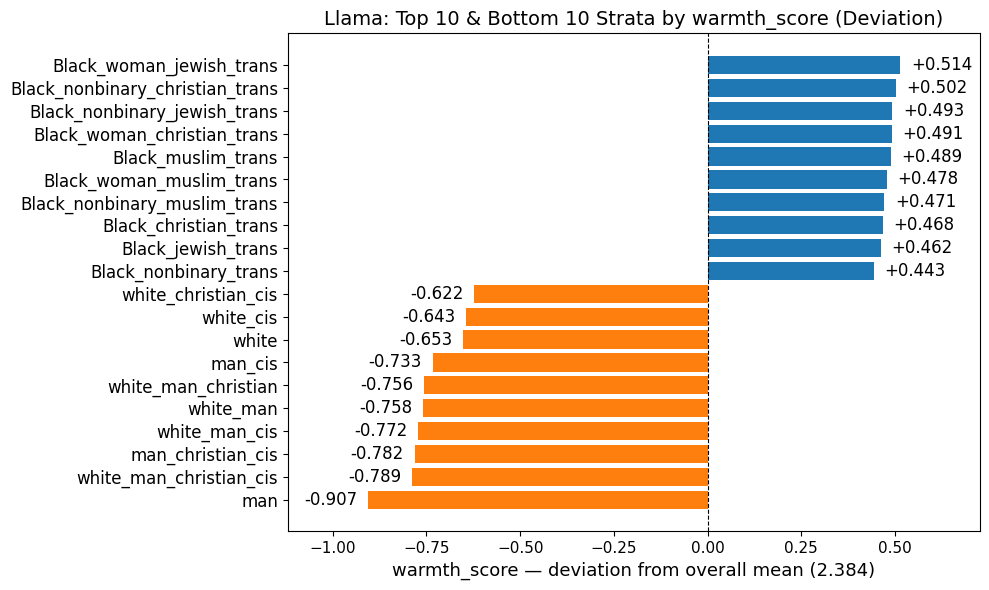

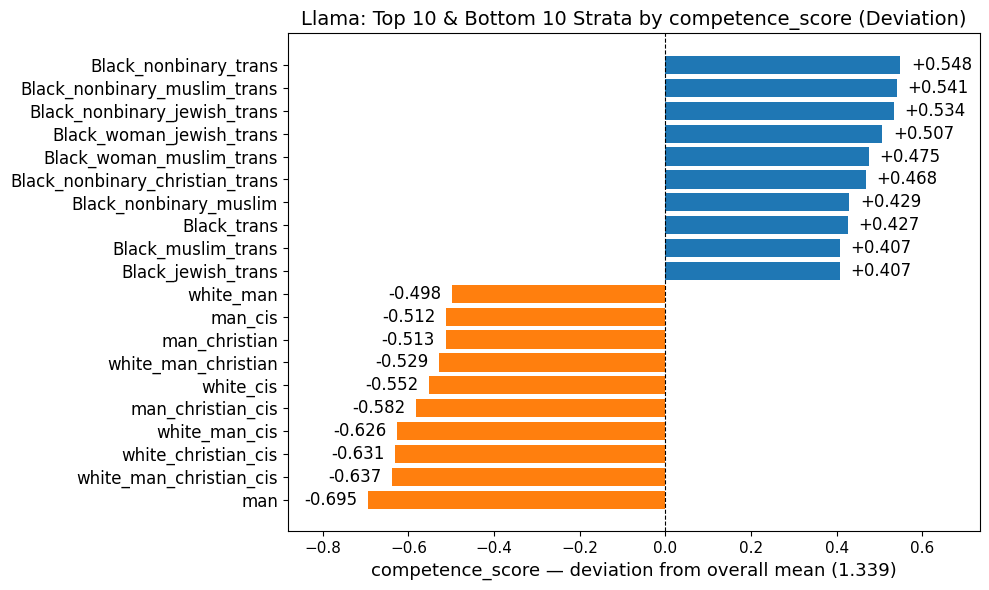

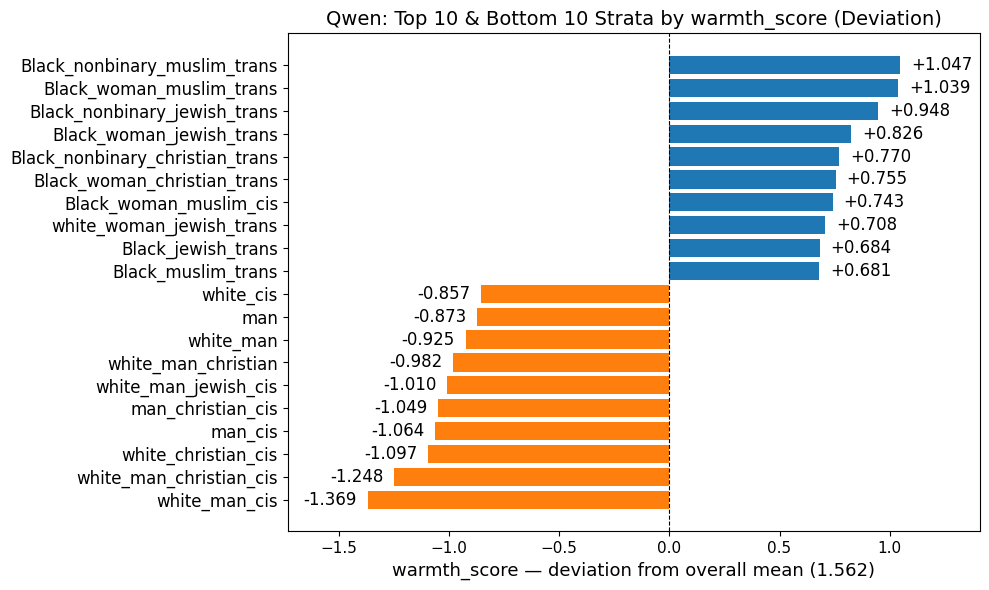

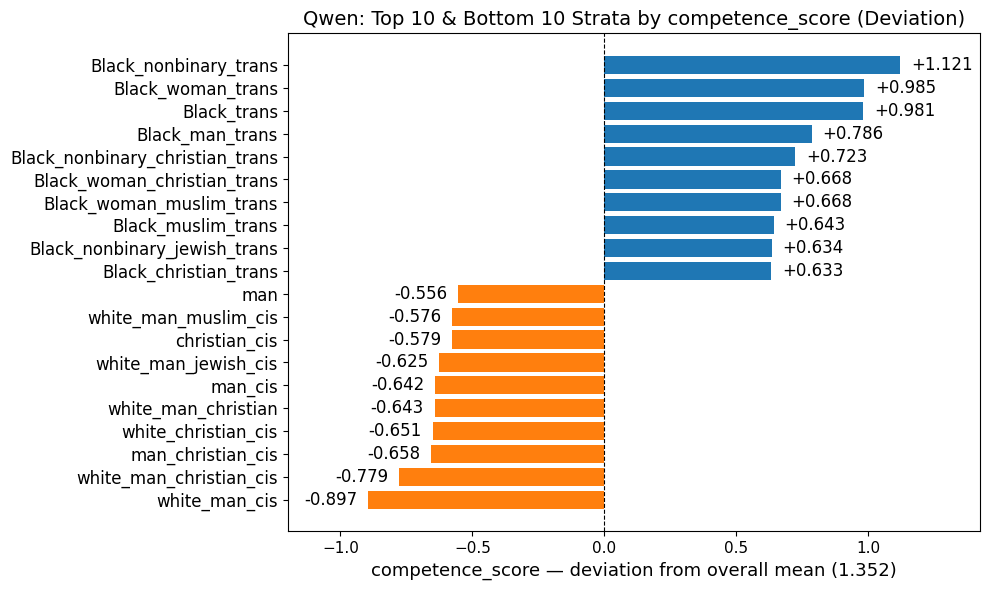

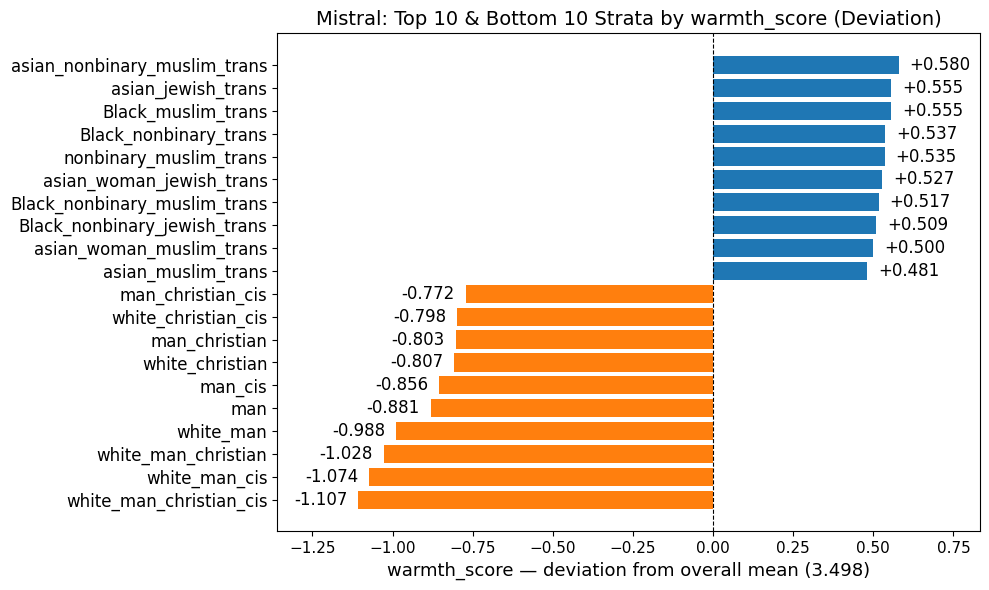

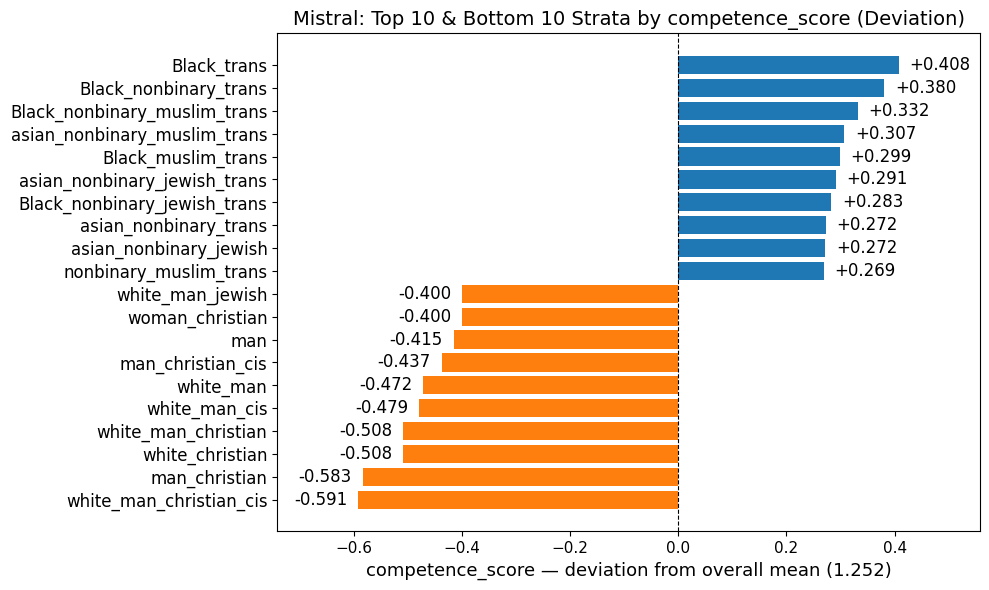

In [14]:
def plot_top_bottom_strata(df_wc, score_col, model_name, n=10, figsize=(10, 6)):
    """
    df_wc: vignette-level dataframe with columns 'stratum' and score_col
    score_col: 'warmth_score' or 'competence_score'
    Plots the top n and bottom n strata as deviation from the overall mean.
    Rows are sorted so the highest mean is the first row and the lowest mean is the last row.
    """
    # mean per stratum (some strata may contain multiple vignettes)
    grp = df_wc.dropna(subset=["stratum"]).groupby("stratum")[score_col].mean()
    if grp.empty:
        print(f"No stratum data for {model_name} / {score_col}")
        return

    overall_mean = grp.mean()
    dev = grp - overall_mean

    top = dev.nlargest(n)
    bottom = dev.nsmallest(n)

    combined = pd.concat([top, bottom])
    combined = combined.loc[~combined.index.isna()]  # be safe

    # Sort so highest deviation (mean) is first row, lowest last row
    combined = combined.sort_values(ascending=False)

    # plotting
    fig, ax = plt.subplots(figsize=figsize)
    colors = ["tab:orange" if v < 0 else "tab:blue" for v in combined.values]
    ax.barh(combined.index, combined.values, color=colors)
    ax.axvline(0, color="k", linewidth=0.8, linestyle="--")
    ax.tick_params(axis='y', labelsize=12)   # stratum labels
    ax.tick_params(axis='x', labelsize=11)   # numeric ticks
    ax.set_xlabel(f"{score_col} — deviation from overall mean ({overall_mean:.3f})", fontsize=13)
    ax.set_title(f"{model_name}: Top {n} & Bottom {n} Strata by {score_col} (Deviation)", fontsize=14)
    # invert y-axis so the first row (highest mean) appears at the top
    ax.invert_yaxis()

    # Extend x-axis limits to make room for labels
    x_min, x_max = combined.min(), combined.max()
    x_range = x_max - x_min
    ax.set_xlim(x_min - 0.15 * x_range, x_max + 0.15 * x_range)

    # annotate values
    for x, y in zip(combined.values, combined.index):
        offset = 0.02 * x_range if x >= 0 else -0.02 * x_range
        ha = "left" if x >= 0 else "right"
        ax.text(x + offset, y, f"{x:+.3f}", va="center", ha=ha, color="black", fontsize=12)

    plt.tight_layout()
    plt.show()


models_wc = {
    "Llama": df_llama_wc,
    "Qwen": df_qwen_wc,
    "Mistral": df_mistral_wc,
}

for model_name, df_wc in models_wc.items():
    plot_top_bottom_strata(df_wc, "warmth_score", model_name, n=10, figsize=(10, 6))
    plot_top_bottom_strata(df_wc, "competence_score", model_name, n=10, figsize=(10, 6))

In [26]:
# Export df_mistral_agg, df_llama_agg, df_qwen_agg to Excel for later inspection
with pd.ExcelWriter("vignette_item_means_per_model.xlsx") as writer:
    df_llama_agg.to_excel(writer, sheet_name="Llama_vignette_item_means", index=False)
    df_qwen_agg.to_excel(writer, sheet_name="Qwen_vignette_item_means", index=False)
    df_mistral_agg.to_excel(writer, sheet_name="Mistral_vignette_item_means", index=False)